# DeepFashion 10,000-Image Training Subset Builder

This notebook:
1. Loads `list_eval_partition.txt` and selects the first 10,000 `train` images.
2. Loads `list_category_img.txt` for category labels.
3. Loads `list_attr_img.txt` and `list_attr_cloth.txt`.
4. Keeps only strict color-related binary attributes.
5. Merges everything and saves `final_subset.csv`.
6. Plots color attribute frequencies for sanity checks.
7. Copies subset images from `img/` to `data/subset_images/` while preserving folder structure, then validates copied/missing files.


In [111]:
from pathlib import Path
import pandas as pd
import re

In [112]:
# Check if PyTorch is installed and if CUDA is available
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("CUDA version used by torch:", torch.version.cuda)

CUDA available: True
GPU name: NVIDIA GeForce RTX 3070
CUDA version used by torch: 12.1


In [113]:
# Paths aligned to the current project layout.
PROJECT_ROOT = Path('.').resolve()
EVAL_FILE = PROJECT_ROOT / 'Eval' / 'list_eval_partition.txt'
CATEGORY_FILE = PROJECT_ROOT / 'Anno_coarse' / 'list_category_img.txt'
ATTR_IMG_FILE = PROJECT_ROOT / 'Anno_coarse' / 'list_attr_img.txt'
ATTR_CLOTH_FILE = PROJECT_ROOT / 'Anno_coarse' / 'list_attr_cloth.txt'
OUTPUT_REP_FILE = PROJECT_ROOT / 'final_subset_representative.csv'
N_IMAGES = 10_000

required_files = [EVAL_FILE, CATEGORY_FILE, ATTR_IMG_FILE, ATTR_CLOTH_FILE]
missing_files = [str(p) for p in required_files if not p.exists()]
if missing_files:
    raise FileNotFoundError('Missing required files:\n' + '\n'.join(missing_files))

print('Using files:')
print(' EVAL_FILE        =', EVAL_FILE)
print(' CATEGORY_FILE    =', CATEGORY_FILE)
print(' ATTR_IMG_FILE    =', ATTR_IMG_FILE)
print(' ATTR_CLOTH_FILE  =', ATTR_CLOTH_FILE)
print(' OUTPUT_REP_FILE  =', OUTPUT_REP_FILE)


Using files:
 EVAL_FILE        = C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\Eval\list_eval_partition.txt
 CATEGORY_FILE    = C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\Anno_coarse\list_category_img.txt
 ATTR_IMG_FILE    = C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\Anno_coarse\list_attr_img.txt
 ATTR_CLOTH_FILE  = C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\Anno_coarse\list_attr_cloth.txt
 OUTPUT_REP_FILE  = C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\final_subset_representative.csv


In [114]:
def read_deepfashion_table(file_path: Path) -> pd.DataFrame:
    # For files like list_eval_partition.txt and list_category_img.txt.
    return pd.read_csv(file_path, sep=r'\s+', skiprows=1)


def read_attr_cloth_table(file_path: Path) -> pd.DataFrame:
    # attribute_name can contain spaces, so split on 2+ spaces only.
    return pd.read_csv(file_path, sep=r'\s{2,}', engine='python', skiprows=1)


def get_color_attribute_names(attribute_names: list[str]) -> tuple[list[int], list[str]]:
    # Strict word-boundary color matching: matches 'red' or 'dark red', not 'embroidered'/'shirred'.
    color_keywords = [
        'black', 'blue', 'brown', 'green', 'grey', 'gray',
        'orange', 'pink', 'purple', 'red', 'white', 'yellow'
    ]
    pattern = re.compile(
        r'(?<![A-Za-z])(?:' + '|'.join(map(re.escape, color_keywords)) + r')(?![A-Za-z])',
        flags=re.IGNORECASE,
    )

    color_info = [
        (idx, name)
        for idx, name in enumerate(attribute_names)
        if pattern.search(str(name))
    ]

    color_indices = [idx for idx, _ in color_info]
    color_attributes = [name for _, name in color_info]
    return color_indices, color_attributes


def extract_color_attributes_for_images(
    attr_img_file: Path,
    target_images: pd.Series,
    color_indices: list[int],
    color_attribute_names: list[str],
) -> pd.DataFrame:
    target_set = set(target_images.tolist())
    rows = []

    with open(attr_img_file, 'r', encoding='utf-8') as f:
        next(f)  # row count
        next(f)  # header

        for line in f:
            parts = line.strip().split()
            if not parts:
                continue

            image_name = parts[0]
            if image_name not in target_set:
                continue

            attr_values = parts[1:]
            if max(color_indices, default=-1) >= len(attr_values):
                raise ValueError(
                    f'Attribute row for {image_name} has {len(attr_values)} values, ' +
                    f'but needs index {max(color_indices)}.'
                )

            row = {'image_name': image_name}
            for idx, attr_name in zip(color_indices, color_attribute_names):
                row[attr_name] = 1 if int(attr_values[idx]) > 0 else 0

            rows.append(row)

    return pd.DataFrame(rows)


In [115]:
# 1) Representative 10,000 train images (random but reproducible)
eval_df = read_deepfashion_table(EVAL_FILE)
train_pool = eval_df.loc[eval_df['evaluation_status'] == 'train', 'image_name']
train_images = train_pool.sample(n=N_IMAGES, random_state=42)

print(f'Train pool size: {len(train_pool)}')
print(f'Selected representative train images: {len(train_images)}')


Train pool size: 209222
Selected representative train images: 10000


In [116]:
# 2) Category labels from list_category_img.txt
category_df = read_deepfashion_table(CATEGORY_FILE)
category_subset = category_df[
    category_df['image_name'].isin(train_images)
][['image_name', 'category_label']].copy()

# Convert to 0-indexed labels (0-49) for model compatibility.
category_subset['category_label'] = category_subset['category_label'].astype(int) - 1

print(f'Category rows: {len(category_subset)}')
print('Category label min/max:', category_subset['category_label'].min(), category_subset['category_label'].max())


Category rows: 10000
Category label min/max: 0 47


In [117]:
# 3) Color-related attribute names from list_attr_cloth.txt
attr_cloth_df = read_attr_cloth_table(ATTR_CLOTH_FILE)
attribute_names = attr_cloth_df['attribute_name'].astype(str).tolist()

color_indices, color_attributes = get_color_attribute_names(attribute_names)

print(f'Color attributes found: {len(color_attributes)}')
print(color_attributes[:30])


Color attributes found: 2
['pink', 'red']


In [118]:
# 4) Keep only target images + color attributes from list_attr_img.txt
color_attr_subset = extract_color_attributes_for_images(
    ATTR_IMG_FILE,
    train_images,
    color_indices,
    color_attributes,
)

existing_color_attributes = [
    col for col in color_attributes if col in color_attr_subset.columns
]

print(f'Color attribute rows: {len(color_attr_subset)}')
print(f'Color attribute columns: {len(existing_color_attributes)}')


Color attribute rows: 10000
Color attribute columns: 2


In [119]:
# 5) Merge and save representative subset
final_df = category_subset.merge(color_attr_subset, on='image_name', how='inner')
final_df.to_csv(OUTPUT_REP_FILE, index=False)

print(f'Saved {len(final_df)} rows and {final_df.shape[1]} columns to: {OUTPUT_REP_FILE}')
final_df.head()


Saved 10000 rows and 4 columns to: C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\final_subset_representative.csv


,image_name,category_label,pink,red
0,img/Sheer_Pleated-Front_Blouse/img_00000021.jpg,2,0,0
1,img/Sheer_Pleated-Front_Blouse/img_00000100.jpg,2,0,0
2,img/Sheer_Pleated-Front_Blouse/img_00000149.jpg,2,0,0
3,img/Sheer_Woven_Blouse/img_00000009.jpg,2,0,0
4,img/Sheer_Woven_Blouse/img_00000034.jpg,2,1,0


Final DataFrame columns:
['image_name', 'category_label', 'pink', 'red']

Color attribute columns used:
['pink', 'red']


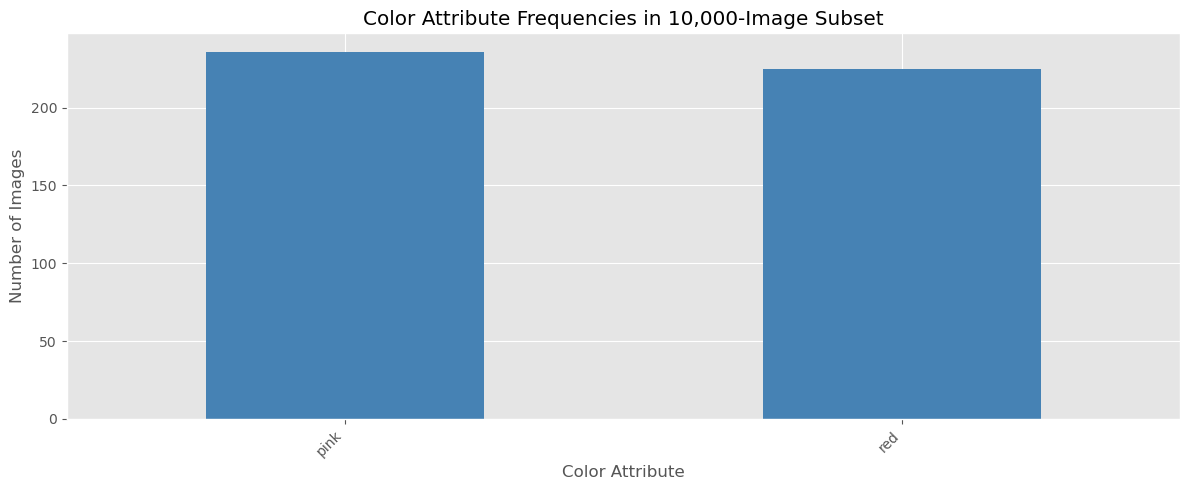

In [120]:
# 6) Sanity check: print final columns and plot color-attribute frequencies
import matplotlib.pyplot as plt

print('Final DataFrame columns:')
print(final_df.columns.tolist())
print('\nColor attribute columns used:')
print(existing_color_attributes)

if existing_color_attributes:
    color_counts = final_df[existing_color_attributes].sum().sort_values(ascending=False)

    plt.figure(figsize=(12, 5))
    color_counts.plot(kind='bar', color='steelblue')
    plt.title('Color Attribute Frequencies in 10,000-Image Subset')
    plt.xlabel('Color Attribute')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No color attributes found to plot.')


## 7) Copy Subset Images and Validate

This step reads `final_subset.csv`, copies listed images from `img/` to `data/subset_images/`, keeps relative folders, and reports missing files.

In [121]:
import shutil
import zipfile
from pathlib import PurePosixPath

CSV_PATH = OUTPUT_REP_FILE
IMG_SRC_ROOT = PROJECT_ROOT / 'img'
IMG_ZIP_PATH = PROJECT_ROOT / 'img.zip'
DATA_ROOT = PROJECT_ROOT / 'data'
OLD_SUBSET_DIR = DATA_ROOT / 'subset_images'
UNBALANCED_BACKUP_DIR = DATA_ROOT / 'subset_images_unbalanced_alphabetical'
REP_SUBSET_DIR = DATA_ROOT / 'subset_images_representative'

if not CSV_PATH.exists():
    raise FileNotFoundError(f'CSV not found: {CSV_PATH}')

# Preserve old unbalanced extraction by renaming subset_images/ once.
if OLD_SUBSET_DIR.exists() and not UNBALANCED_BACKUP_DIR.exists():
    OLD_SUBSET_DIR.rename(UNBALANCED_BACKUP_DIR)
    print(f'Renamed old folder: {OLD_SUBSET_DIR} -> {UNBALANCED_BACKUP_DIR}')
elif OLD_SUBSET_DIR.exists() and UNBALANCED_BACKUP_DIR.exists():
    print('Both old and backup folders exist; leaving old folder unchanged.')
else:
    print('No old subset_images folder found to rename.')

subset_df = pd.read_csv(CSV_PATH)
if 'image_name' not in subset_df.columns:
    raise ValueError(f"'image_name' column not found in {CSV_PATH}")

image_names = subset_df['image_name'].dropna().astype(str).str.strip().tolist()
REP_SUBSET_DIR.mkdir(parents=True, exist_ok=True)

def rel_under_img(image_name: str) -> Path:
    p = PurePosixPath(image_name)
    parts = list(p.parts)
    if parts and parts[0].lower() == 'img':
        parts = parts[1:]
    return Path(*parts)

missing_files = []
copied_count = 0

if IMG_SRC_ROOT.exists():
    for image_name in image_names:
        rel_path = rel_under_img(image_name)
        src_path = IMG_SRC_ROOT / rel_path
        dst_path = REP_SUBSET_DIR / rel_path

        if src_path.exists():
            dst_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_path)
            copied_count += 1
        else:
            missing_files.append(image_name)

elif IMG_ZIP_PATH.exists():
    with zipfile.ZipFile(IMG_ZIP_PATH, 'r') as zf:
        name_set = set(zf.namelist())
        for image_name in image_names:
            zip_member = PurePosixPath(image_name).as_posix()
            rel_path = rel_under_img(image_name)
            dst_path = REP_SUBSET_DIR / rel_path

            if zip_member in name_set:
                dst_path.parent.mkdir(parents=True, exist_ok=True)
                with zf.open(zip_member) as src_f, open(dst_path, 'wb') as dst_f:
                    shutil.copyfileobj(src_f, dst_f)
                copied_count += 1
            else:
                missing_files.append(image_name)
else:
    raise FileNotFoundError(
        f'Neither source folder nor zip was found. Looked for: {IMG_SRC_ROOT} and {IMG_ZIP_PATH}'
    )

copied_files_on_disk = sum(1 for p in REP_SUBSET_DIR.rglob('*') if p.is_file())

print(f'CSV rows: {len(image_names)}')
print(f'Copied files this run: {copied_count}')
print(f'Files currently in {REP_SUBSET_DIR}: {copied_files_on_disk}')
print(f'Missing files: {len(missing_files)}')

if missing_files:
    print('\nFilenames listed in CSV but not found in source:')
    for name in missing_files:
        print(name)


No old subset_images folder found to rename.
CSV rows: 10000
Copied files this run: 10000
Files currently in C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\data\subset_images_representative: 10000
Missing files: 0


## 8) Category Distribution (Imbalance Check)

Map 0-indexed labels in `final_df` to category names from `Anno_coarse/list_category_cloth.txt` and visualize class balance.

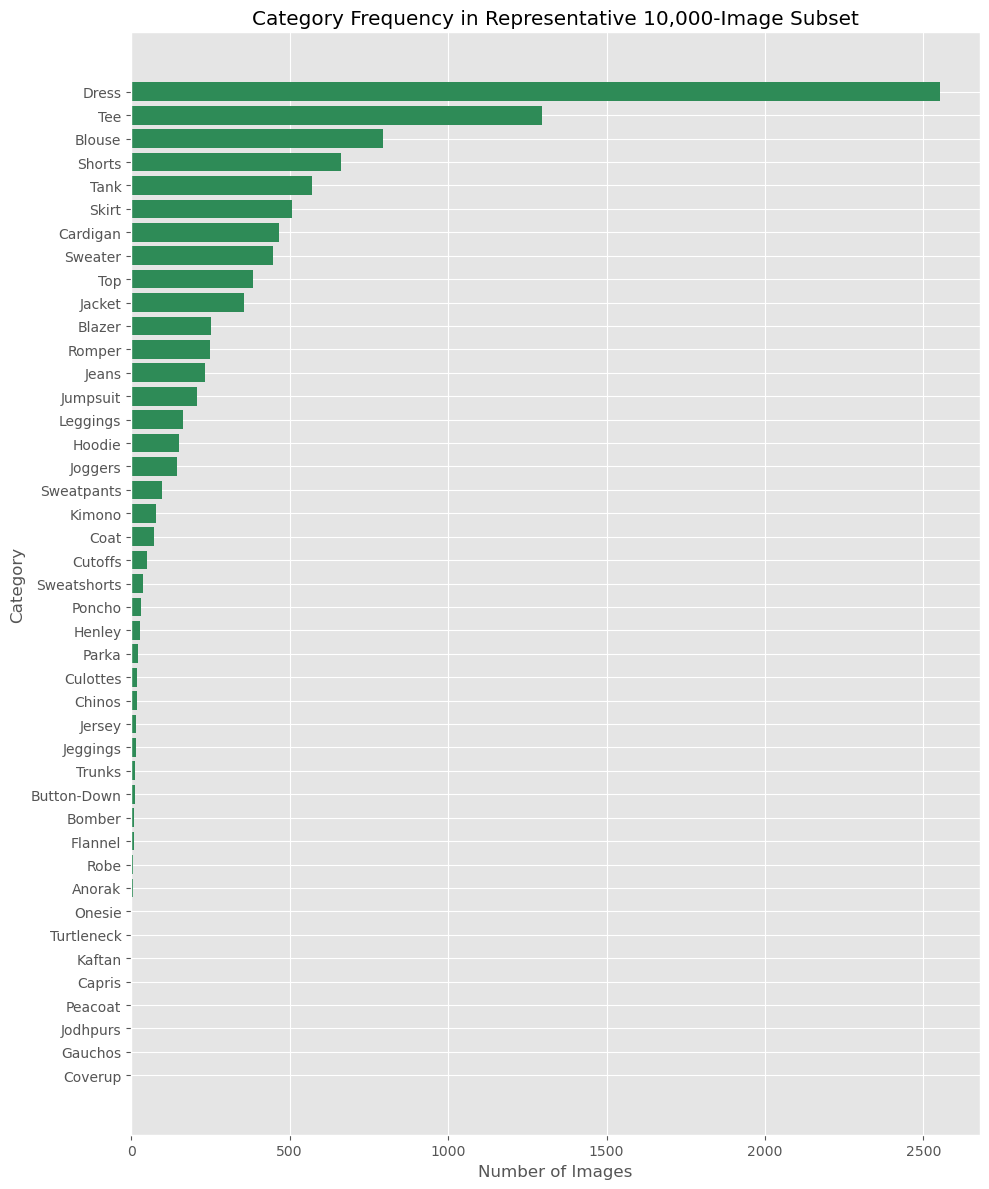

Top 3 categories (representative sample):
category_name  count
        Dress   2551
          Tee   1298
       Blouse    794

Bottom 3 categories (representative sample):
category_name  count
     Jodhpurs      1
      Gauchos      1
      Coverup      1

Top 3 represent 46.43% of the representative subset (n=10000).


In [122]:
# Category distribution analysis for representative sample (report/EDA)
import matplotlib.pyplot as plt

CATEGORY_CLOTH_FILE = PROJECT_ROOT / 'Anno_coarse' / 'list_category_cloth.txt'
if not CATEGORY_CLOTH_FILE.exists():
    raise FileNotFoundError(f'Category file not found: {CATEGORY_CLOTH_FILE}')

if 'final_df' not in globals():
    raise NameError('final_df not found. Run the previous cells first.')

category_cloth_df = pd.read_csv(
    CATEGORY_CLOTH_FILE,
    sep=r'\s{2,}',
    engine='python',
    skiprows=1,
)
category_cloth_df = category_cloth_df.reset_index(drop=True)
category_cloth_df['category_label_1idx'] = category_cloth_df.index + 1
category_cloth_df['category_label_0idx'] = category_cloth_df['category_label_1idx'] - 1

label_to_name = dict(zip(category_cloth_df['category_label_0idx'], category_cloth_df['category_name']))

category_counts = final_df['category_label'].value_counts().sort_values(ascending=False)
plot_df = category_counts.rename_axis('category_label').reset_index(name='count')
plot_df['category_name'] = plot_df['category_label'].map(label_to_name).fillna('Unknown')

plt.figure(figsize=(10, 12))
plt.barh(plot_df['category_name'], plot_df['count'], color='seagreen')
plt.gca().invert_yaxis()
plt.title('Category Frequency in Representative 10,000-Image Subset')
plt.xlabel('Number of Images')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

top3 = plot_df.head(3)
bottom3 = plot_df.tail(3)
top3_pct = (top3['count'].sum() / len(final_df)) * 100

print('Top 3 categories (representative sample):')
print(top3[['category_name', 'count']].to_string(index=False))
print('\nBottom 3 categories (representative sample):')
print(bottom3[['category_name', 'count']].to_string(index=False))
print(f"\nTop 3 represent {top3_pct:.2f}% of the representative subset (n={len(final_df)}).")


## 9) Representative Color Frequency (Compared to Alphabetical)

Load `final_subset_representative.csv`, compute color frequencies, visualize them, and compare active color features against the previous alphabetical subset.

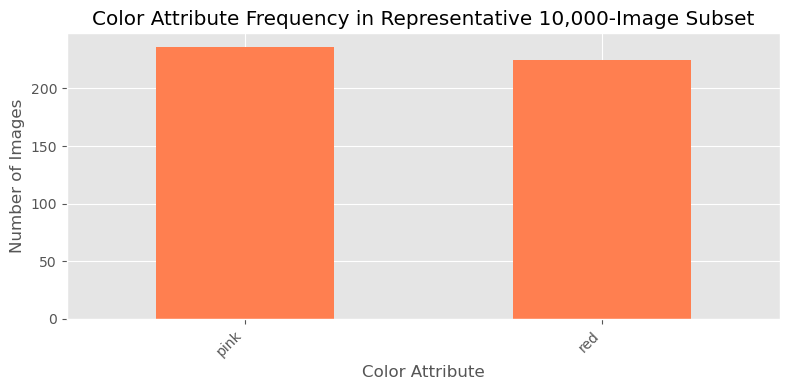

Representative color columns: ['pink', 'red']
Representative active color features: 2
Representative active feature names: ['pink', 'red']

Comparison to previous alphabetical subset:
- Previous active color features: 2
- Representative active color features: 2
- Change in active feature count: +0
- Previous active names: ['red', 'pink']


In [123]:
# Representative color frequency analysis
import re
import matplotlib.pyplot as plt

REP_CSV = PROJECT_ROOT / 'final_subset_representative.csv'
OLD_CSV = PROJECT_ROOT / 'final_subset.csv'  # previous alphabetical subset (if available)

if not REP_CSV.exists():
    raise FileNotFoundError(f'Representative CSV not found: {REP_CSV}')

rep_df = pd.read_csv(REP_CSV)

# Strict color keyword matching for column selection.
color_keywords = ['black', 'blue', 'brown', 'green', 'grey', 'gray', 'orange', 'pink', 'purple', 'red', 'white', 'yellow']
pattern = re.compile(
    r'(?<![A-Za-z])(?:' + '|'.join(map(re.escape, color_keywords)) + r')(?![A-Za-z])',
    flags=re.IGNORECASE,
)

non_feature_cols = {'image_name', 'category_label'}
rep_color_cols = [
    c for c in rep_df.columns
    if c not in non_feature_cols and pattern.search(str(c))
]

if not rep_color_cols:
    raise ValueError('No refined color columns found in final_subset_representative.csv')

rep_color_counts = rep_df[rep_color_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
rep_color_counts.plot(kind='bar', color='coral')
plt.title('Color Attribute Frequency in Representative 10,000-Image Subset')
plt.xlabel('Color Attribute')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Active feature = a color column with at least one positive sample.
rep_active = rep_color_counts[rep_color_counts > 0]
rep_active_count = len(rep_active)

print('Representative color columns:', rep_color_cols)
print('Representative active color features:', rep_active_count)
print('Representative active feature names:', rep_active.index.tolist())

if OLD_CSV.exists():
    old_df = pd.read_csv(OLD_CSV)
    old_color_cols = [
        c for c in old_df.columns
        if c not in non_feature_cols and pattern.search(str(c))
    ]
    old_color_counts = old_df[old_color_cols].sum().sort_values(ascending=False) if old_color_cols else pd.Series(dtype=float)
    old_active = old_color_counts[old_color_counts > 0]
    old_active_count = len(old_active)

    print('\nComparison to previous alphabetical subset:')
    print(f'- Previous active color features: {old_active_count}')
    print(f'- Representative active color features: {rep_active_count}')
    print(f'- Change in active feature count: {rep_active_count - old_active_count:+d}')
    print(f'- Previous active names: {old_active.index.tolist()}')
else:
    print('\nPrevious alphabetical CSV not found (final_subset.csv), so comparison was skipped.')


## 10) Exact Color Counts: Initial vs Representative

Print exact per-color frequencies for both the initial alphabetical subset and the representative random subset.

In [124]:
# Exact color-count comparison between initial and representative subsets
import re

INITIAL_CSV = PROJECT_ROOT / 'final_subset.csv'
REP_CSV = PROJECT_ROOT / 'final_subset_representative.csv'

if not INITIAL_CSV.exists():
    raise FileNotFoundError(f'Initial subset CSV not found: {INITIAL_CSV}')
if not REP_CSV.exists():
    raise FileNotFoundError(f'Representative subset CSV not found: {REP_CSV}')

initial_df = pd.read_csv(INITIAL_CSV)
rep_df = pd.read_csv(REP_CSV)

color_keywords = ['black', 'blue', 'brown', 'green', 'grey', 'gray', 'orange', 'pink', 'purple', 'red', 'white', 'yellow']
pattern = re.compile(
    r'(?<![A-Za-z])(?:' + '|'.join(map(re.escape, color_keywords)) + r')(?![A-Za-z])',
    flags=re.IGNORECASE,
)

non_feature_cols = {'image_name', 'category_label'}
initial_color_cols = [c for c in initial_df.columns if c not in non_feature_cols and pattern.search(str(c))]
rep_color_cols = [c for c in rep_df.columns if c not in non_feature_cols and pattern.search(str(c))]
all_color_cols = sorted(set(initial_color_cols).union(rep_color_cols))

if not all_color_cols:
    raise ValueError('No refined color columns found in either CSV.')

initial_counts = initial_df.reindex(columns=all_color_cols, fill_value=0).sum()
rep_counts = rep_df.reindex(columns=all_color_cols, fill_value=0).sum()

comparison_df = pd.DataFrame({
    'color': all_color_cols,
    'initial_alphabetical_count': initial_counts.astype(int).values,
    'representative_random_count': rep_counts.astype(int).values,
})
comparison_df['difference_rep_minus_initial'] = (
    comparison_df['representative_random_count'] - comparison_df['initial_alphabetical_count']
)
comparison_df = comparison_df.sort_values('representative_random_count', ascending=False).reset_index(drop=True)

print('Exact color counts (initial vs representative):')
print(comparison_df.to_string(index=False))


Exact color counts (initial vs representative):
color  initial_alphabetical_count  representative_random_count  difference_rep_minus_initial
 pink                         248                          236                           -12
  red                         300                          225                           -75


## 11) Step 3: Data Preparation for Modelling (3 Cells)

Cell 1 = cleaning/splitting, Cell 2 = memory-safe DataLoaders, Cell 3 = first-batch diagnostic + 3x3 verification.

In [125]:
# Step 3 - Cell 1: Data Cleaning & Splitting
import time
import gc
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

t0 = time.time()

REP_CSV = PROJECT_ROOT / 'final_subset_representative.csv'
CATEGORY_CLOTH_FILE = PROJECT_ROOT / 'Anno_coarse' / 'list_category_cloth.txt'
MIN_CLASS_COUNT = 10

if not REP_CSV.exists():
    raise FileNotFoundError(f'Representative CSV not found: {REP_CSV}')
if not CATEGORY_CLOTH_FILE.exists():
    raise FileNotFoundError(f'Category file not found: {CATEGORY_CLOTH_FILE}')

rep_df = pd.read_csv(REP_CSV).copy()
if 'image_name' not in rep_df.columns or 'category_label' not in rep_df.columns:
    raise ValueError('Representative CSV must contain image_name and category_label columns.')
rep_df['category_label'] = rep_df['category_label'].astype(int)

# 0-index -> category name mapping
category_name_df = pd.read_csv(CATEGORY_CLOTH_FILE, sep=r'\s{2,}', engine='python', skiprows=1).reset_index(drop=True)
idx_to_name = {i: name for i, name in enumerate(category_name_df['category_name'].astype(str).tolist())}

# Threshold filtering
class_counts = rep_df['category_label'].value_counts().sort_index()
low_quality_labels = class_counts[class_counts < MIN_CLASS_COUNT].index.tolist()
dropped_images = int(class_counts[class_counts < MIN_CLASS_COUNT].sum()) if low_quality_labels else 0

if low_quality_labels:
    print('Categories removed (<10 samples):')
    for lbl in low_quality_labels:
        print(f"- {idx_to_name.get(lbl, f'Class_{lbl}')} (label={lbl}, count={int(class_counts[lbl])})")
    print(f"Removed {len(low_quality_labels)} categories with <{MIN_CLASS_COUNT} samples, total {dropped_images} images dropped.")
else:
    print(f'No categories removed. All categories have >= {MIN_CLASS_COUNT} samples.')

filtered_df = rep_df[~rep_df['category_label'].isin(low_quality_labels)].copy().reset_index(drop=True)

# Strict 70/15/15 stratified split
train_df, temp_df = train_test_split(
    filtered_df,
    test_size=0.30,
    random_state=42,
    stratify=filtered_df['category_label'],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['category_label'],
)

print(f'Filtered total: {len(filtered_df)}')
print(f'Train: {len(train_df)} ({len(train_df)/len(filtered_df):.1%})')
print(f'Val:   {len(val_df)} ({len(val_df)/len(filtered_df):.1%})')
print(f'Test:  {len(test_df)} ({len(test_df)/len(filtered_df):.1%})')

del rep_df
gc.collect()
print(f'Cell 1 time: {time.time() - t0:.2f}s')


Categories removed (<10 samples):
- Anorak (label=0, count=5)
- Flannel (label=6, count=9)
- Peacoat (label=13, count=2)
- Turtleneck (label=19, count=4)
- Capris (label=20, count=3)
- Gauchos (label=24, count=1)
- Jodhpurs (label=27, count=1)
- Coverup (label=39, count=1)
- Kaftan (label=42, count=4)
- Onesie (label=45, count=4)
- Robe (label=46, count=7)
Removed 11 categories with <10 samples, total 41 images dropped.
Filtered total: 9959
Train: 6971 (70.0%)
Val:   1494 (15.0%)
Test:  1494 (15.0%)
Cell 1 time: 0.28s


In [126]:
# Step 3 - Cell 2: NVMe-Optimized DataLoaders
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import time
from pathlib import Path, PurePosixPath
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

t0 = time.time()

# Torch/CUDA diagnostic
print(f'Torch version: {torch.__version__}')
print(f'Is CUDA ready: {torch.cuda.is_available()}')

if not torch.cuda.is_available():
    print('CUDA is not available in this kernel. Restart the kernel and run this cell first, before any earlier torch import, then re-check.')

REP_IMAGES_ROOT = PROJECT_ROOT / 'data' / 'subset_images_representative'
if not REP_IMAGES_ROOT.exists():
    raise FileNotFoundError(f'Representative image folder not found: {REP_IMAGES_ROOT}')

def resolve_rep_image_path(image_name: str, root: Path) -> Path:
    p = PurePosixPath(str(image_name))
    parts = list(p.parts)
    c1 = root / Path(*parts)
    if c1.exists():
        return c1
    if parts and parts[0].lower() == 'img':
        c2 = root / Path(*parts[1:])
        if c2.exists():
            return c2
        return c2
    return c1

for frame_name, frame in [('train_df', train_df), ('val_df', val_df), ('test_df', test_df)]:
    frame['image_path'] = frame['image_name'].map(lambda x: resolve_rep_image_path(x, REP_IMAGES_ROOT))
    missing = int((~frame['image_path'].map(lambda p: p.exists())).sum())
    if missing > 0:
        raise FileNotFoundError(f"{frame_name} has {missing} missing files under {REP_IMAGES_ROOT}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
img_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class RepresentativeFashionDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        label = int(row['category_label'])
        return img, label

train_ds = RepresentativeFashionDataset(train_df, transform=img_transform)
val_ds = RepresentativeFashionDataset(val_df, transform=img_transform)
test_ds = RepresentativeFashionDataset(test_df, transform=img_transform)

# Memory-safe settings for 16GB RAM system
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

cuda_ok = torch.cuda.is_available()
device = torch.device('cuda' if cuda_ok else 'cpu')
print(f'CUDA available: {cuda_ok}')
if cuda_ok:
    print(f'GPU device: {torch.cuda.get_device_name(0)}')
print(f'Device used: {device}')
print(f'Cell 2 time: {time.time() - t0:.2f}s')


Torch version: 2.5.1+cu121
Is CUDA ready: True
CUDA available: True
GPU device: NVIDIA GeForce RTX 3070
Device used: cuda
Cell 2 time: 1.33s


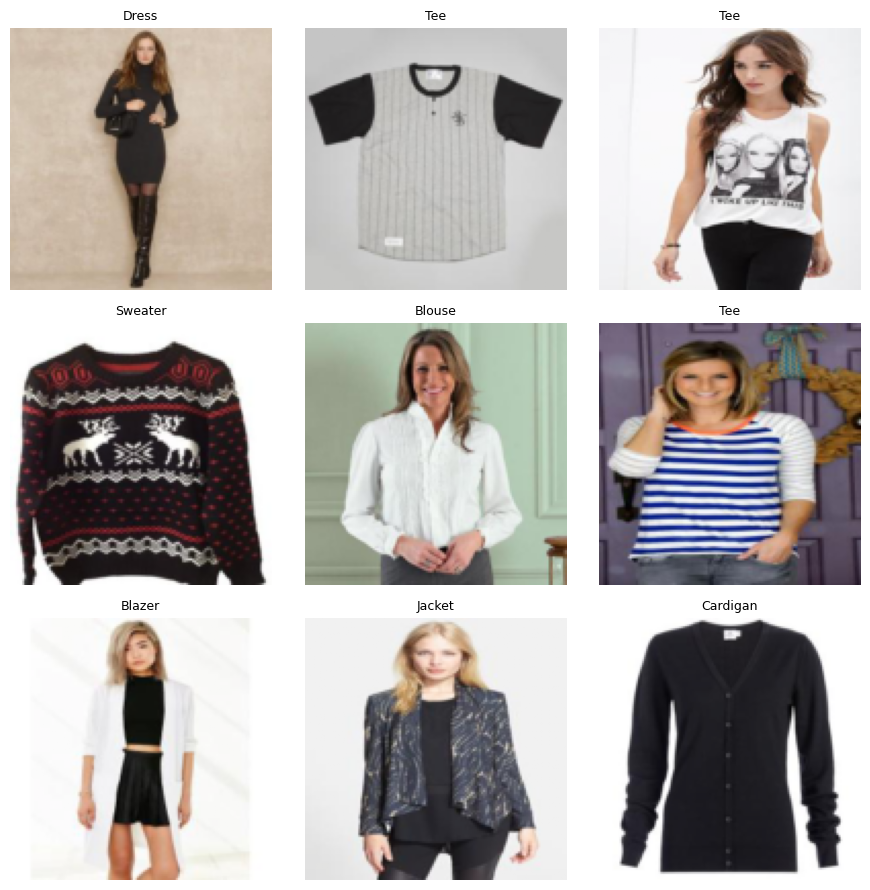

First batch load time from NVMe: 0.18 seconds
Cell 3 time: 1.69s


In [127]:
# Step 3 - Cell 3: First-Batch Diagnostic
import time
import matplotlib.pyplot as plt
import torch

t0 = time.time()

batch_load_start = time.time()
train_images_batch, train_labels_batch = next(iter(train_loader))
first_batch_seconds = time.time() - batch_load_start

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_images_batch = train_images_batch.to(device, non_blocking=False)
train_labels_batch = train_labels_batch.to(device, non_blocking=False)

def denormalize(batch):
    mean = torch.tensor(IMAGENET_MEAN, device=batch.device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=batch.device).view(1, 3, 1, 1)
    return torch.clamp(batch * std + mean, 0, 1)

vis_batch = denormalize(train_images_batch).cpu()
vis_labels = train_labels_batch.cpu()

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    if i >= len(vis_batch):
        ax.axis('off')
        continue
    img = vis_batch[i].permute(1, 2, 0).numpy()
    lbl = int(vis_labels[i])
    ax.imshow(img)
    ax.set_title(idx_to_name.get(lbl, f'Class {lbl}'), fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

print(f'First batch load time from NVMe: {first_batch_seconds:.2f} seconds')
print(f'Cell 3 time: {time.time() - t0:.2f}s')


In [128]:
# Step 4.1: HOG Feature Extraction (CPU-Optimized)
import time
import numpy as np
from PIL import Image
from joblib import Parallel, delayed
from skimage.feature import hog

t0 = time.time()
N_JOBS = 12  # Ryzen 5 5600X: 6 cores / 12 threads
BATCH_SIZE = 500
TARGET_SIZE = (128, 128)
HOG_PARAMS = {
    'orientations': 9,
    'pixels_per_cell': (8, 8),
    'cells_per_block': (2, 2),
    'block_norm': 'L2-Hys',
    'feature_vector': True,
}

def load_and_extract_hog(image_path: str) -> np.ndarray:
    with Image.open(image_path) as img:
        gray = img.convert('L').resize(TARGET_SIZE)
        gray_arr = np.asarray(gray, dtype=np.float32) / 255.0
    return hog(gray_arr, **HOG_PARAMS).astype(np.float32)

def extract_hog_in_batches(image_paths, split_name):
    total = len(image_paths)
    feature_batches = []

    for start in range(0, total, BATCH_SIZE):
        end = min(start + BATCH_SIZE, total)
        batch_paths = image_paths[start:end]

        batch_feats = Parallel(n_jobs=N_JOBS, backend='threading')(
            delayed(load_and_extract_hog)(img_path) for img_path in batch_paths
        )
        feature_batches.append(np.vstack(batch_feats))
        print(f'[{split_name}] Processed {end}/{total} images')

    return np.vstack(feature_batches)

train_paths = train_df['image_path'].astype(str).tolist()
val_paths = val_df['image_path'].astype(str).tolist()
test_paths = test_df['image_path'].astype(str).tolist()

X_train_hog = extract_hog_in_batches(train_paths, 'train')
X_val_hog = extract_hog_in_batches(val_paths, 'val')
X_test_hog = extract_hog_in_batches(test_paths, 'test')

y_train = train_df['category_label'].to_numpy(dtype=np.int64)
y_val = val_df['category_label'].to_numpy(dtype=np.int64)
y_test = test_df['category_label'].to_numpy(dtype=np.int64)

hog_dir = PROJECT_ROOT / 'data' / 'hog_features'
hog_dir.mkdir(parents=True, exist_ok=True)

np.save(hog_dir / 'X_train_hog.npy', X_train_hog)
np.save(hog_dir / 'X_val_hog.npy', X_val_hog)
np.save(hog_dir / 'X_test_hog.npy', X_test_hog)
np.save(hog_dir / 'y_train.npy', y_train)
np.save(hog_dir / 'y_val.npy', y_val)
np.save(hog_dir / 'y_test.npy', y_test)

total_seconds = time.time() - t0
print(f'HOG extraction done in {total_seconds:.2f} seconds')
print(f'Final HOG feature vector shape: ({X_train_hog.shape[1]},)')
print(f'X_train_hog: {X_train_hog.shape} | X_val_hog: {X_val_hog.shape} | X_test_hog: {X_test_hog.shape}')
print(f'Saved HOG arrays to: {hog_dir.resolve()}')


[train] Processed 500/6971 images
[train] Processed 1000/6971 images
[train] Processed 1500/6971 images
[train] Processed 2000/6971 images
[train] Processed 2500/6971 images
[train] Processed 3000/6971 images
[train] Processed 3500/6971 images
[train] Processed 4000/6971 images
[train] Processed 4500/6971 images
[train] Processed 5000/6971 images
[train] Processed 5500/6971 images
[train] Processed 6000/6971 images
[train] Processed 6500/6971 images
[train] Processed 6971/6971 images
[val] Processed 500/1494 images
[val] Processed 1000/1494 images
[val] Processed 1494/1494 images
[test] Processed 500/1494 images
[test] Processed 1000/1494 images
[test] Processed 1494/1494 images
HOG extraction done in 36.29 seconds
Final HOG feature vector shape: (8100,)
X_train_hog: (6971, 8100) | X_val_hog: (1494, 8100) | X_test_hog: (1494, 8100)
Saved HOG arrays to: C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\data\hog_features


In [129]:
# Step 4.15: PCA Compression for Faster Traditional ML
import time
import gc
import numpy as np
from sklearn.decomposition import PCA

t0 = time.time()
PCA_COMPONENTS = 500

hog_dir = PROJECT_ROOT / 'data' / 'hog_features'

# Load HOG arrays if this kernel does not already have them in memory
if 'X_train_hog' not in globals():
    X_train_hog = np.load(hog_dir / 'X_train_hog.npy')
if 'X_val_hog' not in globals():
    X_val_hog = np.load(hog_dir / 'X_val_hog.npy')
if 'X_test_hog' not in globals():
    X_test_hog = np.load(hog_dir / 'X_test_hog.npy')

print(f'Running PCA with n_components={PCA_COMPONENTS} on HOG features...')
pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_hog)
X_val_pca = pca.transform(X_val_hog)
X_test_pca = pca.transform(X_test_hog)

print(f'PCA complete. Shapes -> train: {X_train_pca.shape}, val: {X_val_pca.shape}, test: {X_test_pca.shape}')
print(f'Explained variance retained: {pca.explained_variance_ratio_.sum():.4f}')

# Persist PCA arrays for quick re-runs
np.save(hog_dir / 'X_train_pca.npy', X_train_pca)
np.save(hog_dir / 'X_val_pca.npy', X_val_pca)
np.save(hog_dir / 'X_test_pca.npy', X_test_pca)
print(f'Saved PCA arrays to: {hog_dir.resolve()}')

# RAM cleanup after compression
del X_train_hog, X_val_hog, X_test_hog
gc.collect()
print('Freed raw HOG arrays from RAM (X_train_hog, X_val_hog, X_test_hog).')
print(f'Cell 4.15 total time: {time.time() - t0:.2f}s')


Running PCA with n_components=500 on HOG features...
PCA complete. Shapes -> train: (6971, 500), val: (1494, 500), test: (1494, 500)
Explained variance retained: 0.7317
Saved PCA arrays to: C:\Users\Hoang Long\Desktop\MSIN0097 Predictive Analytics Individual CW\data\hog_features
Freed raw HOG arrays from RAM (X_train_hog, X_val_hog, X_test_hog).
Cell 4.15 total time: 3.75s


In [130]:
# Step 4.2: Traditional ML Tournament (SVM vs Random Forest)
import time
import numpy as np
import pandas as pd
import psutil
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.utils import shuffle

t0 = time.time()
MEMORY_REDLINE_GB = 14.0
TRAIN_SUBSET_SIZE = 5000
RANDOM_STATE = 42
RF_THREADS = 12

hog_dir = PROJECT_ROOT / 'data' / 'hog_features'

# Ensure labels are available
if 'y_train' not in globals():
    y_train = np.load(hog_dir / 'y_train.npy')
if 'y_test' not in globals():
    y_test = np.load(hog_dir / 'y_test.npy')

# Load PCA arrays from memory or disk
if 'X_train_pca' not in globals():
    X_train_pca = np.load(hog_dir / 'X_train_pca.npy')
if 'X_test_pca' not in globals():
    X_test_pca = np.load(hog_dir / 'X_test_pca.npy')

base_bytes = X_train_pca.nbytes + X_test_pca.nbytes + y_train.nbytes + y_test.nbytes
estimated_peak_gb = (base_bytes * 8) / (1024 ** 3)

use_subset = estimated_peak_gb > MEMORY_REDLINE_GB and X_train_pca.shape[0] > TRAIN_SUBSET_SIZE
if use_subset:
    X_train_model, y_train_model = shuffle(X_train_pca, y_train, random_state=RANDOM_STATE)
    X_train_model = X_train_model[:TRAIN_SUBSET_SIZE]
    y_train_model = y_train_model[:TRAIN_SUBSET_SIZE]
    print(f'Memory safeguard ON (est. peak {estimated_peak_gb:.2f} GB > {MEMORY_REDLINE_GB:.1f} GB). Using train subset: {TRAIN_SUBSET_SIZE}.')
else:
    X_train_model, y_train_model = X_train_pca, y_train
    print(f'Memory safeguard OFF (est. peak {estimated_peak_gb:.2f} GB). Using full train set: {len(y_train_model)}.')

ram = psutil.virtual_memory()
print(f'Current RAM usage: {ram.percent:.1f}% ({ram.used / (1024 ** 3):.2f} GB used / {ram.total / (1024 ** 3):.2f} GB total)')

# Data scaling for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_pca)

# Model 1 - Linear SVM on PCA features
svm_model = LinearSVC(random_state=RANDOM_STATE, dual='auto', max_iter=5000, verbose=1)
print('Starting SVM fit...')
svm_t0 = time.time()
svm_model.fit(X_train_scaled, y_train_model)
svm_train_time = time.time() - svm_t0
print(f'SVM fit complete in {svm_train_time:.2f}s. Starting SVM prediction...')
svm_pred = svm_model.predict(X_test_scaled)
print('SVM prediction complete.')

# Model 2 - Random Forest on PCA features
print('Utilizing 12 threads on Ryzen 5600X for Random Forest')
rf_model = RandomForestClassifier(
    n_estimators=100,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=2,
)
print('Starting Random Forest fit...')
rf_t0 = time.time()
rf_model.fit(X_train_model, y_train_model)
rf_train_time = time.time() - rf_t0
print(f'Random Forest fit complete in {rf_train_time:.2f}s. Starting RF prediction...')
rf_pred = rf_model.predict(X_test_pca)
print('Random Forest prediction complete.')

print(f'SVM training time: {svm_train_time:.2f}s')
print(f'RF  training time: {rf_train_time:.2f}s')

svm_report = classification_report(y_test, svm_pred, output_dict=True, zero_division=0)
rf_report = classification_report(y_test, rf_pred, output_dict=True, zero_division=0)
svm_df = pd.DataFrame(svm_report).T
rf_df = pd.DataFrame(rf_report).T
side_by_side = pd.concat({'SVM': svm_df, 'RF': rf_df}, axis=1)
print('\\nClassification Report (Test) - Side by Side:')
display(side_by_side.round(4))

svm_acc = accuracy_score(y_test, svm_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_f1 = f1_score(y_test, svm_pred, average='macro')
rf_f1 = f1_score(y_test, rf_pred, average='macro')

if (svm_f1 > rf_f1) or (np.isclose(svm_f1, rf_f1) and svm_acc >= rf_acc):
    winner = 'SVM'
else:
    winner = 'Random Forest'

print(f'SVM  - Accuracy: {svm_acc:.4f}, Macro-F1: {svm_f1:.4f}')
print(f'RF   - Accuracy: {rf_acc:.4f}, Macro-F1: {rf_f1:.4f}')
print(f'Winner baseline for CNN comparison: {winner}')
print(f'Cell 4.2 total time: {time.time() - t0:.2f}s')


Memory safeguard OFF (est. peak 0.13 GB). Using full train set: 6971.
Current RAM usage: 89.0% (14.17 GB used / 15.93 GB total)
Starting SVM fit...
[LibLinear]SVM fit complete in 44.16s. Starting SVM prediction...
SVM prediction complete.
Utilizing 12 threads on Ryzen 5600X for Random Forest
Starting Random Forest fit...
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100
building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100
building tree 34 of 100
building tree 35 of 100
building tree 36 of 100


[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.6s


building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75 of 100
building tree 76 of 100
building tree 77 of 100
building tree 78

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.9s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


SVM                                    RF                   \
             precision  recall f1-score    support precision  recall f1-score   
1               0.1429  0.1579   0.1500    38.0000    0.0000  0.0000   0.0000   
2               0.2319  0.1345   0.1702   119.0000    0.0000  0.0000   0.0000   
3               0.0000  0.0000   0.0000     2.0000    0.0000  0.0000   0.0000   
4               0.0000  0.0000   0.0000     2.0000    0.0000  0.0000   0.0000   
5               0.1852  0.0714   0.1031    70.0000    0.0000  0.0000   0.0000   
8               0.0000  0.0000   0.0000     4.0000    0.0000  0.0000   0.0000   
9               0.1538  0.2727   0.1967    22.0000    0.0000  0.0000   0.0000   
10              0.1282  0.0943   0.1087    53.0000    0.0000  0.0000   0.0000   
11              0.0000  0.0000   0.0000     3.0000    0.0000  0.0000   0.0000   
12              0.0000  0.0000   0.0000     4.0000    0.0000  0.0000   0.0000   
14              0.0000  0.0000   0.0000     5.0000    0.0000  0.0000   0.0000   
15              0.1860  0.1194   0.1455    67.0000    0.0000  0.0000   0.0000   
16              0.2500  0.1882   0.2148    85.0000    0.0000  0.0000   0.0000   
17              0.3825  0.4256   0.4029   195.0000    0.3059  0.2667   0.2849   
18              0.0455  0.0172   0.0250    58.0000    0.0000  0.0000   0.0000   
21              0.0000  0.0000   0.0000     3.0000    0.0000  0.0000   0.0000   
22              0.0000  0.0000   0.0000     2.0000    0.0000  0.0000   0.0000   
23              0.0000  0.0000   0.0000     7.0000    0.0000  0.0000   0.0000   
25              0.1296  0.2000   0.1573    35.0000    0.0000  0.0000   0.0000   
26              0.0000  0.0000   0.0000     3.0000    0.0000  0.0000   0.0000   
28              0.0667  0.0909   0.0769    22.0000    0.0000  0.0000   0.0000   
29              0.1053  0.2500   0.1481    24.0000    0.0000  0.0000   0.0000   
31              0.2787  0.1700   0.2112   100.0000    0.5455  0.0600   0.1081   
32              0.2045  0.1184   0.1500    76.0000    0.0000  0.0000   0.0000   
33              0.0909  0.2000   0.1250    15.0000    0.0000  0.0000   0.0000   
34              0.0000  0.0000   0.0000     5.0000    0.0000  0.0000   0.0000   
35              0.0000  0.0000   0.0000     2.0000    0.0000  0.0000   0.0000   
38              0.0000  0.0000   0.0000    11.0000    0.0000  0.0000   0.0000   
40              0.4710  0.6597   0.5496   382.0000    0.2789  0.9529   0.4315   
41              0.0000  0.0000   0.0000    31.0000    0.0000  0.0000   0.0000   
43              0.0500  0.0833   0.0625    12.0000    0.0000  0.0000   0.0000   
47              0.0370  0.0270   0.0312    37.0000    0.0000  0.0000   0.0000   
accuracy        0.2972  0.2972   0.2972     0.2972    0.2825  0.2825   0.2825   
macro avg       0.0981  0.1025   0.0946  1494.0000    0.0353  0.0400   0.0258   
weighted avg    0.2693  0.2972   0.2733  1494.0000    0.1478  0.2825   0.1548   

                         
                support  
1               38.0000  
2              119.0000  
3                2.0000  
4                2.0000  
5               70.0000  
8                4.0000  
9               22.0000  
10              53.0000  
11               3.0000  
12               4.0000  
14               5.0000  
15              67.0000  
16              85.0000  
17             195.0000  
18              58.0000  
21               3.0000  
22               2.0000  
23               7.0000  
25              35.0000  
26               3.0000  
28              22.0000  
29              24.0000  
31             100.0000  
32              76.0000  
33              15.0000  
34               5.0000  
35               2.0000  
38              11.0000  
40             382.0000  
41              31.0000  
43              12.0000  
47              37.0000  
accuracy         0.2825  
macro avg     1494.0000  
weighted avg  1494.0000

SVM  - Accuracy: 0.2972, Macro-F1: 0.0946
RF   - Accuracy: 0.2825, Macro-F1: 0.0258
Winner baseline for CNN comparison: SVM
Cell 4.2 total time: 47.35s


Contiguous label mapping complete: 32 classes (0 to 31)
Using device: cuda | GPU: NVIDIA GeForce RTX 3070
Epoch 01/20 | Train Loss: 2.6869 | Val Acc: 0.3112
Epoch 02/20 | Train Loss: 2.2667 | Val Acc: 0.3474
Epoch 03/20 | Train Loss: 2.0257 | Val Acc: 0.3601
Epoch 04/20 | Train Loss: 1.8188 | Val Acc: 0.3574
Epoch 05/20 | Train Loss: 1.5932 | Val Acc: 0.3474
Epoch 06/20 | Train Loss: 1.3790 | Val Acc: 0.3400
Epoch 07/20 | Train Loss: 1.1830 | Val Acc: 0.3327
Epoch 08/20 | Train Loss: 0.9830 | Val Acc: 0.3420
Epoch 09/20 | Train Loss: 0.8127 | Val Acc: 0.3427
Epoch 10/20 | Train Loss: 0.6810 | Val Acc: 0.3300
Epoch 11/20 | Train Loss: 0.5639 | Val Acc: 0.3253
Epoch 12/20 | Train Loss: 0.4791 | Val Acc: 0.3353
Epoch 13/20 | Train Loss: 0.4055 | Val Acc: 0.3240
Epoch 14/20 | Train Loss: 0.3517 | Val Acc: 0.3353
Epoch 15/20 | Train Loss: 0.2939 | Val Acc: 0.3273
Epoch 16/20 | Train Loss: 0.2652 | Val Acc: 0.3253
Epoch 17/20 | Train Loss: 0.2403 | Val Acc: 0.3333
Epoch 18/20 | Train Loss: 0

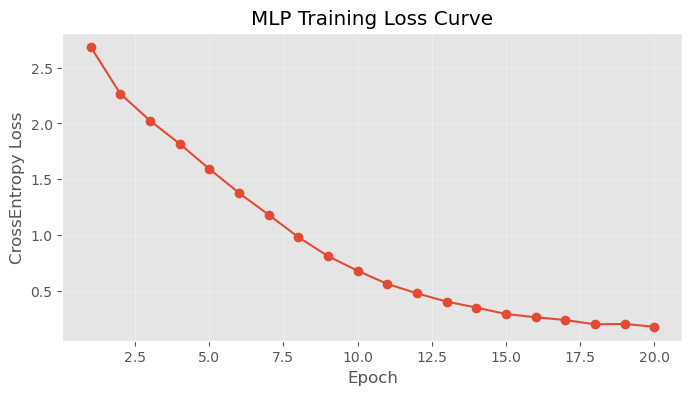

\nFinal Classification Report (MLP on PCA Features):
              precision    recall  f1-score   support

           0       0.25      0.18      0.21        38
           1       0.21      0.24      0.22       119
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.16      0.13      0.14        70
           5       0.00      0.00      0.00         4
           6       0.19      0.18      0.19        22
           7       0.20      0.13      0.16        53
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00         5
          11       0.12      0.12      0.12        67
          12       0.22      0.21      0.21        85
          13       0.37      0.42      0.39       195
          14       0.10      0.07      0.08        58
          15       0.00      0.00      0.00         3
          16       0.00     

In [131]:
# Step 4.3: The Neural Bridge (MLP on GPU)
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

t0 = time.time()
EPOCHS = 20
BATCH_SIZE = 64
LR = 1e-3

hog_dir = PROJECT_ROOT / 'data' / 'hog_features'

# Ensure PCA features and labels are available
if 'X_train_pca' not in globals():
    X_train_pca = np.load(hog_dir / 'X_train_pca.npy')
if 'X_val_pca' not in globals():
    X_val_pca = np.load(hog_dir / 'X_val_pca.npy')
if 'X_test_pca' not in globals():
    X_test_pca = np.load(hog_dir / 'X_test_pca.npy')
if 'y_train' not in globals():
    y_train = np.load(hog_dir / 'y_train.npy')
if 'y_val' not in globals():
    y_val = np.load(hog_dir / 'y_val.npy')
if 'y_test' not in globals():
    y_test = np.load(hog_dir / 'y_test.npy')

# 1) Contiguous label mapping (0..N-1) across train/val/test
all_labels = np.unique(np.concatenate([y_train, y_val, y_test]))
label_to_idx = {int(lbl): i for i, lbl in enumerate(all_labels.tolist())}
idx_to_label = {i: int(lbl) for lbl, i in label_to_idx.items()}

y_train_mapped = np.array([label_to_idx[int(y)] for y in y_train], dtype=np.int64)
y_val_mapped = np.array([label_to_idx[int(y)] for y in y_val], dtype=np.int64)
y_test_mapped = np.array([label_to_idx[int(y)] for y in y_test], dtype=np.int64)
n_classes = len(label_to_idx)
print(f'Contiguous label mapping complete: {n_classes} classes (0 to {n_classes - 1})')

# Convert numpy arrays to torch tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
X_val_t = torch.tensor(X_val_pca, dtype=torch.float32)
X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train_mapped, dtype=torch.long)
y_val_t = torch.tensor(y_val_mapped, dtype=torch.long)
y_test_t = torch.tensor(y_test_mapped, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

# 2) MLP architecture: 500 -> 256 -> 128 -> n_classes
class MLPClassifier(nn.Module):
    def __init__(self, input_dim=500, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

# 3) Hardware acceleration on RTX 3070
if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. Please run in a GPU-enabled kernel to use RTX 3070.')
device = torch.device('cuda')
model = MLPClassifier(input_dim=500, num_classes=n_classes).to(device)
print(f'Using device: {device} | GPU: {torch.cuda.get_device_name(0)}')

# 4) Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # quick validation accuracy snapshot
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    val_acc = correct / max(total, 1)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Acc: {val_acc:.4f}')

# 5) Reporting: loss curve + final classification report
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o')
plt.title('MLP Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('CrossEntropy Loss')
plt.grid(True, alpha=0.3)
plt.show()

model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_true.extend(yb.numpy().tolist())

print('\\nFinal Classification Report (MLP on PCA Features):')
print(classification_report(all_true, all_preds, zero_division=0))
print('SVM benchmark to beat: 29.7% accuracy')
print(f'Cell 4.3 total time: {time.time() - t0:.2f}s')


Using device: cuda | GPU: NVIDIA GeForce RTX 3070
CNN label mapping: 32 classes (0..31)
Epoch 01/12 | Scratch Loss: 3.1919 (val 2.5570) Acc: 0.2564 | Transfer Loss: 2.0291 (val 1.8155) Acc: 0.4398
Epoch 02/12 | Scratch Loss: 2.6683 (val 2.5129) Acc: 0.2624 | Transfer Loss: 1.5728 (val 1.8185) Acc: 0.4746
Epoch 03/12 | Scratch Loss: 2.5974 (val 2.4749) Acc: 0.2778 | Transfer Loss: 1.3102 (val 1.9100) Acc: 0.4518
Epoch 04/12 | Scratch Loss: 2.5602 (val 2.4396) Acc: 0.3099 | Transfer Loss: 1.0339 (val 1.8695) Acc: 0.4980
Epoch 05/12 | Scratch Loss: 2.5066 (val 2.3808) Acc: 0.3146 | Transfer Loss: 0.7763 (val 2.0213) Acc: 0.4806
Epoch 06/12 | Scratch Loss: 2.4734 (val 2.3390) Acc: 0.3133 | Transfer Loss: 0.5857 (val 2.4743) Acc: 0.4705
Epoch 07/12 | Scratch Loss: 2.4527 (val 2.3140) Acc: 0.3253 | Transfer Loss: 0.4490 (val 2.6457) Acc: 0.4451
Epoch 08/12 | Scratch Loss: 2.4135 (val 2.3221) Acc: 0.3333 | Transfer Loss: 0.3283 (val 2.5451) Acc: 0.4672
Epoch 09/12 | Scratch Loss: 2.3919 (val 

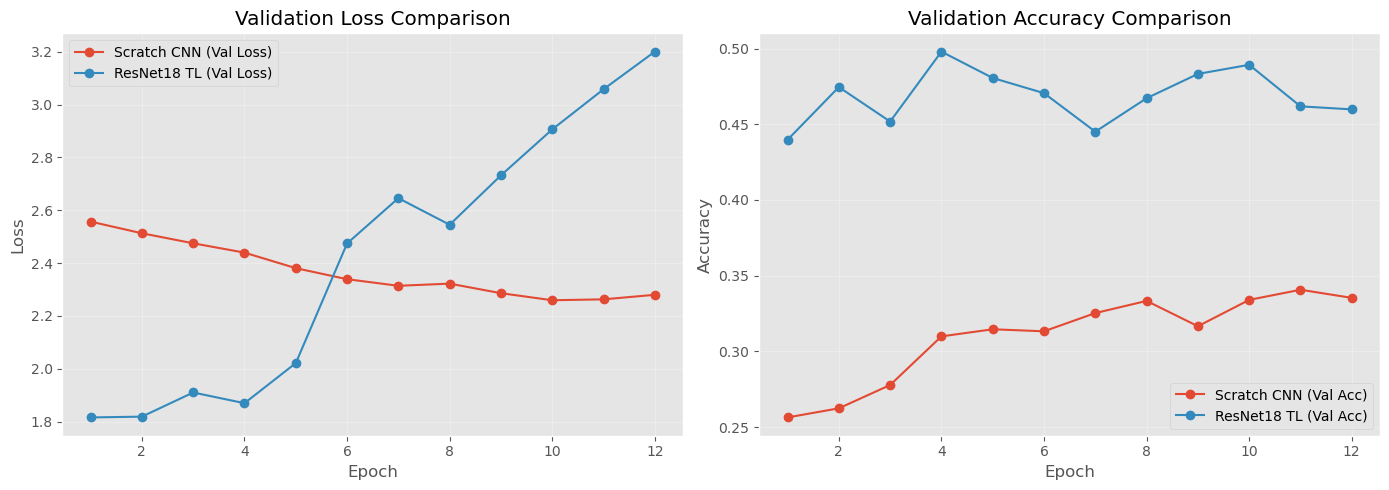

\nClassification Report - Scratch CNN (Test):
              precision    recall  f1-score   support

      Blazer       0.00      0.00      0.00        38
      Blouse       0.00      0.00      0.00       119
      Bomber       0.00      0.00      0.00         2
 Button-Down       0.00      0.00      0.00         2
    Cardigan       0.00      0.00      0.00        70
      Henley       0.00      0.00      0.00         4
      Hoodie       0.00      0.00      0.00        22
      Jacket       0.00      0.00      0.00        53
      Jersey       0.00      0.00      0.00         3
       Parka       0.00      0.00      0.00         4
      Poncho       0.00      0.00      0.00         5
     Sweater       0.00      0.00      0.00        67
        Tank       0.83      0.06      0.11        85
         Tee       0.28      0.55      0.37       195
         Top       0.00      0.00      0.00        58
      Chinos       0.00      0.00      0.00         3
    Culottes       0.00      0.00  

In [132]:
# Step 4.4: The CNN Tournament (Scratch vs. Transfer Learning)
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report

t0 = time.time()
EPOCHS = 12
BATCH_SIZE = 32
LR = 1e-3
IMG_SIZE = 128

if 'train_df' not in globals() or 'val_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError('train_df/val_df/test_df not found. Please run Step 3 first to rebuild image splits and paths.')

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. Please run in a GPU-enabled kernel (RTX 3070).')
device = torch.device('cuda')
print(f'Using device: {device} | GPU: {torch.cuda.get_device_name(0)}')

# Contiguous mapping for stable CrossEntropy targets
all_labels = np.unique(np.concatenate([
    train_df['category_label'].to_numpy(),
    val_df['category_label'].to_numpy(),
    test_df['category_label'].to_numpy(),
]))
label_to_idx = {int(lbl): i for i, lbl in enumerate(all_labels.tolist())}
idx_to_orig = {i: int(lbl) for lbl, i in label_to_idx.items()}
num_classes = len(label_to_idx)
print(f'CNN label mapping: {num_classes} classes (0..{num_classes - 1})')

class ImagePathDataset(Dataset):
    def __init__(self, frame, label_map, transform=None):
        self.paths = frame['image_path'].astype(str).tolist()
        self.labels = [label_map[int(y)] for y in frame['category_label'].tolist()]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

# 1) Data pipeline on raw 128x128 RGB images
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = ImagePathDataset(train_df, label_to_idx, transform=train_tf)
val_ds = ImagePathDataset(val_df, label_to_idx, transform=eval_tf)
test_ds = ImagePathDataset(test_df, label_to_idx, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# 2) Model A: 3-layer scratch CNN
class ScratchCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# 3) Model B: Transfer Learning (ResNet18)
try:
    transfer_model = models.resnet18(weights='IMAGENET1K_V1')
except Exception:
    from torchvision.models import ResNet18_Weights
    transfer_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

for param in transfer_model.parameters():
    param.requires_grad = False
for name, param in transfer_model.named_parameters():
    if name.startswith('layer4'):
        param.requires_grad = True

in_features = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(in_features, num_classes)

scratch_model = ScratchCNN(num_classes).to(device)
transfer_model = transfer_model.to(device)

criterion = nn.CrossEntropyLoss()
scratch_optimizer = torch.optim.Adam(scratch_model.parameters(), lr=LR)
transfer_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, transfer_model.parameters()), lr=LR)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_count += yb.size(0)

    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc

history = {
    'scratch_train_loss': [], 'scratch_val_loss': [], 'scratch_val_acc': [],
    'transfer_train_loss': [], 'transfer_val_loss': [], 'transfer_val_acc': [],
}

for epoch in range(1, EPOCHS + 1):
    s_train_loss, s_train_acc = run_epoch(scratch_model, train_loader, scratch_optimizer)
    s_val_loss, s_val_acc = run_epoch(scratch_model, val_loader, optimizer=None)

    t_train_loss, t_train_acc = run_epoch(transfer_model, train_loader, transfer_optimizer)
    t_val_loss, t_val_acc = run_epoch(transfer_model, val_loader, optimizer=None)

    history['scratch_train_loss'].append(s_train_loss)
    history['scratch_val_loss'].append(s_val_loss)
    history['scratch_val_acc'].append(s_val_acc)
    history['transfer_train_loss'].append(t_train_loss)
    history['transfer_val_loss'].append(t_val_loss)
    history['transfer_val_acc'].append(t_val_acc)

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'Scratch Loss: {s_train_loss:.4f} (val {s_val_loss:.4f}) Acc: {s_val_acc:.4f} | '
        f'Transfer Loss: {t_train_loss:.4f} (val {t_val_loss:.4f}) Acc: {t_val_acc:.4f}'
    )

# 5) Side-by-side monitoring plots (loss + accuracy)
epochs_axis = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_axis, history['scratch_val_loss'], marker='o', label='Scratch CNN (Val Loss)')
axes[0].plot(epochs_axis, history['transfer_val_loss'], marker='o', label='ResNet18 TL (Val Loss)')
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, history['scratch_val_acc'], marker='o', label='Scratch CNN (Val Acc)')
axes[1].plot(epochs_axis, history['transfer_val_acc'], marker='o', label='ResNet18 TL (Val Acc)')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# 6) Final test-set classification reports for both models
def predict_all(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            pred = logits.argmax(dim=1).cpu().numpy()
            preds.extend(pred.tolist())
            trues.extend(yb.numpy().tolist())
    return np.array(trues), np.array(preds)

target_names = []
if 'idx_to_name' in globals():
    for i in range(num_classes):
        orig_lbl = idx_to_orig[i]
        target_names.append(str(idx_to_name.get(orig_lbl, f'Class_{orig_lbl}')))
else:
    target_names = [f'Class_{idx_to_orig[i]}' for i in range(num_classes)]

y_true_s, y_pred_s = predict_all(scratch_model, test_loader)
y_true_t, y_pred_t = predict_all(transfer_model, test_loader)

print('\\nClassification Report - Scratch CNN (Test):')
print(classification_report(y_true_s, y_pred_s, target_names=target_names, zero_division=0))

print('Classification Report - ResNet18 Transfer Learning (Test):')
print(classification_report(y_true_t, y_pred_t, target_names=target_names, zero_division=0))
print(f'Cell 4.4 total time: {time.time() - t0:.2f}s')


[I 2026-03-02 14:27:37,009] A new study created in memory with name: no-name-33739bd1-7350-4017-b77f-cb1becbc190f


Using device: cuda | GPU: NVIDIA GeForce RTX 3070
Optuna tuning over 32 classes
[Trial 00] Epoch 1/6 | train_loss=2.3022 val_loss=1.8038 val_acc=0.4799
[Trial 00] Epoch 2/6 | train_loss=1.5765 val_loss=1.7218 val_acc=0.5100
[Trial 00] Epoch 3/6 | train_loss=1.1981 val_loss=1.7619 val_acc=0.5013
[Trial 00] Epoch 4/6 | train_loss=0.8526 val_loss=1.8216 val_acc=0.5000
[Trial 00] Epoch 5/6 | train_loss=0.5906 val_loss=1.9342 val_acc=0.4739


[I 2026-03-02 14:29:25,795] Trial 0 finished with value: 1.7217703459253273 and parameters: {'learning_rate': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'dropout': 0.4195981825434215}. Best is trial 0 with value: 1.7217703459253273.


[Trial 00] Epoch 6/6 | train_loss=0.3755 val_loss=2.0136 val_acc=0.5060
[Trial 01] Epoch 1/6 | train_loss=2.0385 val_loss=1.7538 val_acc=0.4719
[Trial 01] Epoch 2/6 | train_loss=1.5187 val_loss=1.7695 val_acc=0.4746
[Trial 01] Epoch 3/6 | train_loss=1.2158 val_loss=1.8683 val_acc=0.4739
[Trial 01] Epoch 4/6 | train_loss=0.9598 val_loss=1.9647 val_acc=0.4866
[Trial 01] Epoch 5/6 | train_loss=0.6643 val_loss=2.1974 val_acc=0.4772


[I 2026-03-02 14:31:15,054] Trial 1 finished with value: 1.7538021984828045 and parameters: {'learning_rate': 0.0006251373574521745, 'weight_decay': 2.9380279387035354e-06, 'dropout': 0.24679835610086082}. Best is trial 0 with value: 1.7217703459253273.


...

[I 2026-03-02 14:39:27,205] Trial 10 pruned. 


[Trial 11] Epoch 1/6 | train_loss=2.1286 val_loss=1.7737 val_acc=0.4625
[Trial 11] Epoch 2/6 | train_loss=1.6725 val_loss=1.7221 val_acc=0.4846
[Trial 11] Epoch 3/6 | train_loss=1.4453 val_loss=1.8214 val_acc=0.4933
[Trial 11] Epoch 4/6 | train_loss=1.2865 val_loss=1.8329 val_acc=0.4746
[Trial 11] Epoch 5/6 | train_loss=1.0973 val_loss=1.9543 val_acc=0.4578


[I 2026-03-02 14:41:16,639] Trial 11 finished with value: 1.722126615414498 and parameters: {'learning_rate': 0.0008306050731972224, 'weight_decay': 0.000894688812545702, 'dropout': 0.4306092538129464}. Best is trial 0 with value: 1.7217703459253273.


[Trial 11] Epoch 6/6 | train_loss=0.9798 val_loss=1.9375 val_acc=0.4806
\nBest Trial:
  Number: 0
  Value (best val loss): 1.721770
  Params: {'learning_rate': 0.0001329291894316216, 'weight_decay': 0.0007114476009343421, 'dropout': 0.4195981825434215}
\nTraining Champion Model for 15 epochs...
Champion Epoch 01/15 | train_loss=2.2988 val_loss=1.8305 val_acc=0.4679
Champion Epoch 02/15 | train_loss=1.5860 val_loss=1.7194 val_acc=0.4900
Champion Epoch 03/15 | train_loss=1.2043 val_loss=1.7728 val_acc=0.4906
Champion Epoch 04/15 | train_loss=0.8483 val_loss=1.8377 val_acc=0.4853
Champion Epoch 05/15 | train_loss=0.5653 val_loss=1.9670 val_acc=0.4739
Champion Epoch 06/15 | train_loss=0.3802 val_loss=2.0021 val_acc=0.4859
Champion Epoch 07/15 | train_loss=0.2438 val_loss=2.1220 val_acc=0.4786
Champion Epoch 08/15 | train_loss=0.1659 val_loss=2.1361 val_acc=0.4813
Champion Epoch 09/15 | train_loss=0.1196 val_loss=2.2192 val_acc=0.4866
Champion Epoch 10/15 | train_loss=0.0913 val_loss=2.2794

C:\Users\Hoang Long\AppData\Local\Temp\ipykernel_15188\2176802763.py:253: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


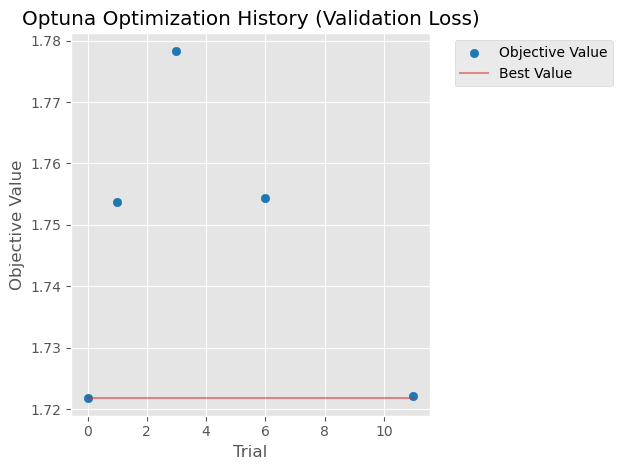

Cell 4.5 total time: 1099.24s


In [133]:
# Step 4.5: Automated Hyperparameter Tuning with Optuna
import time
import copy
import sys
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report

# 1) Setup: install/import Optuna
try:
    import optuna
except ImportError:
    print('Optuna not found. Installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna

t0 = time.time()
N_TRIALS = 12  # within requested 10-15
TRIAL_EPOCHS = 6
CHAMPION_EPOCHS = 15
BATCH_SIZE = 32
IMG_SIZE = 128
RANDOM_STATE = 42

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. Please run in a GPU-enabled kernel (RTX 3070).')
device = torch.device('cuda')
print(f'Using device: {device} | GPU: {torch.cuda.get_device_name(0)}')

if 'train_df' not in globals() or 'val_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError('train_df/val_df/test_df are missing. Please run Step 3 first.')

# Build contiguous labels (0..N-1) for stable CrossEntropy targets
all_labels = np.unique(np.concatenate([
    train_df['category_label'].to_numpy(),
    val_df['category_label'].to_numpy(),
    test_df['category_label'].to_numpy(),
]))
label_to_idx = {int(lbl): i for i, lbl in enumerate(all_labels.tolist())}
idx_to_orig = {i: int(lbl) for lbl, i in label_to_idx.items()}
num_classes = len(label_to_idx)
print(f'Optuna tuning over {num_classes} classes')

class ImagePathDataset(Dataset):
    def __init__(self, frame, label_map, transform=None):
        self.paths = frame['image_path'].astype(str).tolist()
        self.labels = [label_map[int(y)] for y in frame['category_label'].tolist()]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_loader = DataLoader(
    ImagePathDataset(train_df, label_to_idx, transform=train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    ImagePathDataset(val_df, label_to_idx, transform=eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    ImagePathDataset(test_df, label_to_idx, transform=eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True
)

def build_resnet18(dropout_rate, num_classes):
    try:
        model = models.resnet18(weights='IMAGENET1K_V1')
    except Exception:
        from torchvision.models import ResNet18_Weights
        model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

    # Freeze early layers and tune later features + head
    for p in model.parameters():
        p.requires_grad = False
    for name, p in model.named_parameters():
        if name.startswith('layer4'):
            p.requires_grad = True

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, num_classes),
    )
    return model.to(device)

criterion = nn.CrossEntropyLoss()
best_global = {'val_loss': np.inf}

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_count += yb.size(0)
    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_count = 0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_count += yb.size(0)
    return total_loss / max(total_count, 1)

# 2) Objective function to minimize validation loss
def objective(trial):
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)

    model = build_resnet18(dropout_rate=dropout, num_classes=num_classes)
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_trial_val = np.inf
    for epoch in range(1, TRIAL_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_loss, val_acc = evaluate(model, val_loader)
        trial.report(val_loss, step=epoch)

        # 4) Manual early pruning: if 10% worse than current best by epoch 3
        if epoch == 3 and np.isfinite(best_global['val_loss']):
            if val_loss > best_global['val_loss'] * 1.10:
                msg = 'Pruned at epoch 3: val_loss {:.4f} is >10% worse than best {:.4f}'.format(val_loss, best_global['val_loss'])
                raise optuna.TrialPruned(msg)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_loss < best_trial_val:
            best_trial_val = val_loss

        print(
            f'[Trial {trial.number:02d}] Epoch {epoch}/{TRIAL_EPOCHS} '
            f'| train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
        )

    if best_trial_val < best_global['val_loss']:
        best_global['val_loss'] = best_trial_val
    return best_trial_val

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=2)
study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, gc_after_trial=True)

# 5) Best trial + Champion Model training
best = study.best_trial
print('\\nBest Trial:')
print(f'  Number: {best.number}')
print(f'  Value (best val loss): {best.value:.6f}')
print(f'  Params: {best.params}')

champion = build_resnet18(dropout_rate=best.params['dropout'], num_classes=num_classes)
champion_opt = torch.optim.Adam(
    filter(lambda p: p.requires_grad, champion.parameters()),
    lr=best.params['learning_rate'],
    weight_decay=best.params['weight_decay'],
)

champion_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_state = None
best_val_loss = np.inf

print('\\nTraining Champion Model for 15 epochs...')
for epoch in range(1, CHAMPION_EPOCHS + 1):
    tr_loss = train_one_epoch(champion, train_loader, champion_opt)
    va_loss, va_acc = evaluate(champion, val_loader)
    champion_history['train_loss'].append(tr_loss)
    champion_history['val_loss'].append(va_loss)
    champion_history['val_acc'].append(va_acc)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = copy.deepcopy(champion.state_dict())

    print(f'Champion Epoch {epoch:02d}/{CHAMPION_EPOCHS} | train_loss={tr_loss:.4f} val_loss={va_loss:.4f} val_acc={va_acc:.4f}')

if best_state is not None:
    champion.load_state_dict(best_state)

# Final test report
champion.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = champion(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_true.extend(yb.numpy().tolist())

target_names = []
if 'idx_to_name' in globals():
    for i in range(num_classes):
        orig_lbl = idx_to_orig[i]
        target_names.append(str(idx_to_name.get(orig_lbl, f'Class_{orig_lbl}')))
else:
    target_names = [f'Class_{idx_to_orig[i]}' for i in range(num_classes)]

print('\\nChampion Model Classification Report (Test):')
print(classification_report(all_true, all_preds, target_names=target_names, zero_division=0))

# 6) Optimization history visualization
print('Optuna Optimization History:')
try:
    from optuna.visualization.matplotlib import plot_optimization_history
    ax = plot_optimization_history(study)
    ax.set_title('Optuna Optimization History (Validation Loss)')
    plt.tight_layout()
    plt.show()
except Exception:
    complete_vals = [t.value for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None]
    if len(complete_vals) > 0:
        x = np.arange(1, len(complete_vals) + 1)
        y_best = np.minimum.accumulate(np.array(complete_vals))
        plt.figure(figsize=(7, 4))
        plt.plot(x, complete_vals, marker='o', label='Trial Value')
        plt.plot(x, y_best, marker='s', label='Best-So-Far')
        plt.title('Optuna Optimization History (Fallback Plot)')
        plt.xlabel('Completed Trial')
        plt.ylabel('Validation Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print('No completed trials available for history plot.')

print(f'Cell 4.5 total time: {time.time() - t0:.2f}s')


Using device: cuda | GPU: NVIDIA GeForce RTX 3070
ViT classes: 32 (expected around 32)
Step 4.6 deep augmentation not found; using equivalent deep augmentation in Step 4.7.
Epoch 01/15 | LR=0.000208 | Train Loss=2.7190 | Val Loss=2.6610 | Val Acc=0.2590
Epoch 02/15 | LR=0.000417 | Train Loss=2.6805 | Val Loss=2.6501 | Val Acc=0.2550
Epoch 03/15 | LR=0.000625 | Train Loss=2.6646 | Val Loss=2.6310 | Val Acc=0.2631
Epoch 04/15 | LR=0.000625 | Train Loss=2.6467 | Val Loss=2.6271 | Val Acc=0.2564
Epoch 05/15 | LR=0.000625 | Train Loss=2.6288 | Val Loss=2.6230 | Val Acc=0.2584
Epoch 06/15 | LR=0.000625 | Train Loss=2.6140 | Val Loss=2.6170 | Val Acc=0.2651
Epoch 07/15 | LR=0.000625 | Train Loss=2.5948 | Val Loss=2.6684 | Val Acc=0.2564
Epoch 08/15 | LR=0.000625 | Train Loss=2.5726 | Val Loss=2.5935 | Val Acc=0.2570
Epoch 09/15 | LR=0.000625 | Train Loss=2.5622 | Val Loss=2.5476 | Val Acc=0.2704
Epoch 10/15 | LR=0.000625 | Train Loss=2.5490 | Val Loss=2.5598 | Val Acc=0.2704
Epoch 11/15 | LR=

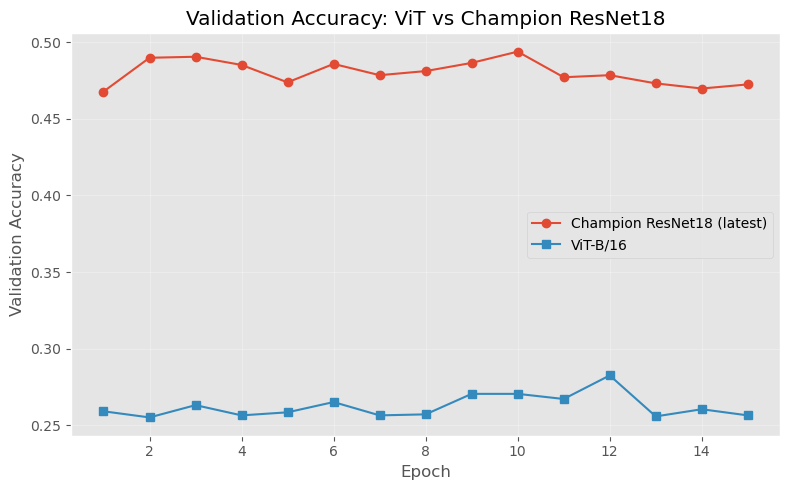

\nFinal Classification Report - ViT-B/16 (Test):
              precision    recall  f1-score   support

      Blazer       0.00      0.00      0.00        38
      Blouse       0.00      0.00      0.00       119
      Bomber       0.00      0.00      0.00         2
 Button-Down       0.00      0.00      0.00         2
    Cardigan       0.00      0.00      0.00        70
      Henley       0.00      0.00      0.00         4
      Hoodie       0.00      0.00      0.00        22
      Jacket       0.00      0.00      0.00        53
      Jersey       0.00      0.00      0.00         3
       Parka       0.00      0.00      0.00         4
      Poncho       0.00      0.00      0.00         5
     Sweater       0.00      0.00      0.00        67
        Tank       0.00      0.00      0.00        85
         Tee       0.24      0.14      0.17       195
         Top       0.00      0.00      0.00        58
      Chinos       0.00      0.00      0.00         3
    Culottes       0.00      0.0

In [134]:
# Step 4.7: The Final Challenge - Vision Transformer (ViT)
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, accuracy_score

t0 = time.time()
BASE_LR = 0.000625
WARMUP_EPOCHS = 3
TOTAL_EPOCHS = 15
BATCH_SIZE = 16
IMG_SIZE = 224

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available. Please run in a GPU-enabled kernel (RTX 3070).')
device = torch.device('cuda')
print(f'Using device: {device} | GPU: {torch.cuda.get_device_name(0)}')

if 'train_df' not in globals() or 'val_df' not in globals() or 'test_df' not in globals():
    raise RuntimeError('train_df/val_df/test_df missing. Run Step 3 first.')

# Contiguous labels for CrossEntropy stability
all_labels = np.unique(np.concatenate([
    train_df['category_label'].to_numpy(),
    val_df['category_label'].to_numpy(),
    test_df['category_label'].to_numpy(),
]))
label_to_idx = {int(lbl): i for i, lbl in enumerate(all_labels.tolist())}
idx_to_orig = {i: int(lbl) for lbl, i in label_to_idx.items()}
num_classes = len(label_to_idx)
print(f'ViT classes: {num_classes} (expected around 32)')

class ImagePathDataset(Dataset):
    def __init__(self, frame, label_map, transform=None):
        self.paths = frame['image_path'].astype(str).tolist()
        self.labels = [label_map[int(y)] for y in frame['category_label'].tolist()]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, self.labels[idx]

# 4) Data pipeline: use Step 4.6 deep augmentation if present; otherwise equivalent deep augmentation
if 'train_tf_deep' in globals():
    train_tf_vit = train_tf_deep
    print('Using deep augmentation from Step 4.6: train_tf_deep')
else:
    train_tf_vit = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=8),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    print('Step 4.6 deep augmentation not found; using equivalent deep augmentation in Step 4.7.')

eval_tf_vit = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_loader = DataLoader(ImagePathDataset(train_df, label_to_idx, transform=train_tf_vit), batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(ImagePathDataset(val_df, label_to_idx, transform=eval_tf_vit), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(ImagePathDataset(test_df, label_to_idx, transform=eval_tf_vit), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# 1) Model setup: pretrained ViT
try:
    vit_model = models.vit_b_16(weights='IMAGENET1K_V1')
except Exception:
    from torchvision.models import ViT_B_16_Weights
    vit_model = models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

# 2) Custom head for our classes
in_features = vit_model.heads.head.in_features
vit_model.heads = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_features, num_classes))
vit_model = vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vit_model.parameters(), lr=BASE_LR)

# 3) Linear warmup for first 3 epochs, then hold base LR
def lr_lambda(epoch_idx):
    e = epoch_idx + 1
    if e <= WARMUP_EPOCHS:
        return e / float(WARMUP_EPOCHS)
    return 1.0
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

vit_history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_state = None
best_val_acc = -1.0

for epoch in range(1, TOTAL_EPOCHS + 1):
    vit_model.train()
    train_loss_sum = 0.0
    train_count = 0
    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = vit_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * xb.size(0)
        train_count += yb.size(0)

    vit_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)
            logits = vit_model(xb)
            vloss = criterion(logits, yb)
            preds = logits.argmax(dim=1)
            val_loss_sum += vloss.item() * xb.size(0)
            val_correct += (preds == yb).sum().item()
            val_count += yb.size(0)

    epoch_train_loss = train_loss_sum / max(train_count, 1)
    epoch_val_loss = val_loss_sum / max(val_count, 1)
    epoch_val_acc = val_correct / max(val_count, 1)
    vit_history['train_loss'].append(epoch_train_loss)
    vit_history['val_loss'].append(epoch_val_loss)
    vit_history['val_acc'].append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in vit_model.state_dict().items()}

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:02d}/{TOTAL_EPOCHS} | LR={current_lr:.6f} | Train Loss={epoch_train_loss:.4f} | Val Loss={epoch_val_loss:.4f} | Val Acc={epoch_val_acc:.4f}')
    scheduler.step()

if best_state is not None:
    vit_model.load_state_dict(best_state)

# 6) Comparison plot: ViT vs Champion ResNet18 validation accuracy
resnet_val_acc = None
resnet_label = 'Champion ResNet18'
if 'champion_history_46' in globals() and 'val_acc' in champion_history_46:
    resnet_val_acc = champion_history_46['val_acc']
    resnet_label = 'Champion ResNet18 (Step 4.6)'
elif 'champion_history' in globals() and 'val_acc' in champion_history:
    resnet_val_acc = champion_history['val_acc']
    resnet_label = 'Champion ResNet18 (latest)'

epochs_axis = np.arange(1, len(vit_history['val_acc']) + 1)
plt.figure(figsize=(8, 5))
if resnet_val_acc is not None and len(resnet_val_acc) > 0:
    x_res = np.arange(1, len(resnet_val_acc) + 1)
    plt.plot(x_res, resnet_val_acc, marker='o', label=resnet_label)
else:
    print('ResNet champion validation history not found; plotting ViT only.')
plt.plot(epochs_axis, vit_history['val_acc'], marker='s', label='ViT-B/16')
plt.title('Validation Accuracy: ViT vs Champion ResNet18')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Final test evaluation
vit_model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        logits = vit_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(yb.numpy().tolist())

target_names = []
if 'idx_to_name' in globals():
    for i in range(num_classes):
        orig_lbl = idx_to_orig[i]
        target_names.append(str(idx_to_name.get(orig_lbl, f'Class_{orig_lbl}')))
else:
    target_names = [f'Class_{idx_to_orig[i]}' for i in range(num_classes)]

vit_test_acc = accuracy_score(y_true, y_pred)
print('\\nFinal Classification Report - ViT-B/16 (Test):')
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))
print(f'ViT Test Accuracy: {vit_test_acc:.4f}')

resnet_best = None
if resnet_val_acc is not None and len(resnet_val_acc) > 0:
    resnet_best = float(np.max(resnet_val_acc))
    print(f'Best {resnet_label} Validation Accuracy: {resnet_best:.4f}')

if resnet_best is None:
    print('Did Attention outperform Convolution? Cannot conclude automatically (ResNet reference missing).')
else:
    verdict = 'Yes' if best_val_acc > resnet_best else 'No'
    print(f'Did Attention outperform Convolution? {verdict}')

print(f'Cell 4.7 total time: {time.time() - t0:.2f}s')


,Model,Accuracy,Macro F1,Weighted F1
0,SVM (Baseline),0.2972,0.0946,0.2733
1,ResNet18 (Optimized),0.4250,0.1439,0.3910
2,Vision Transformer (Final),0.2764,0.0291,0.1450


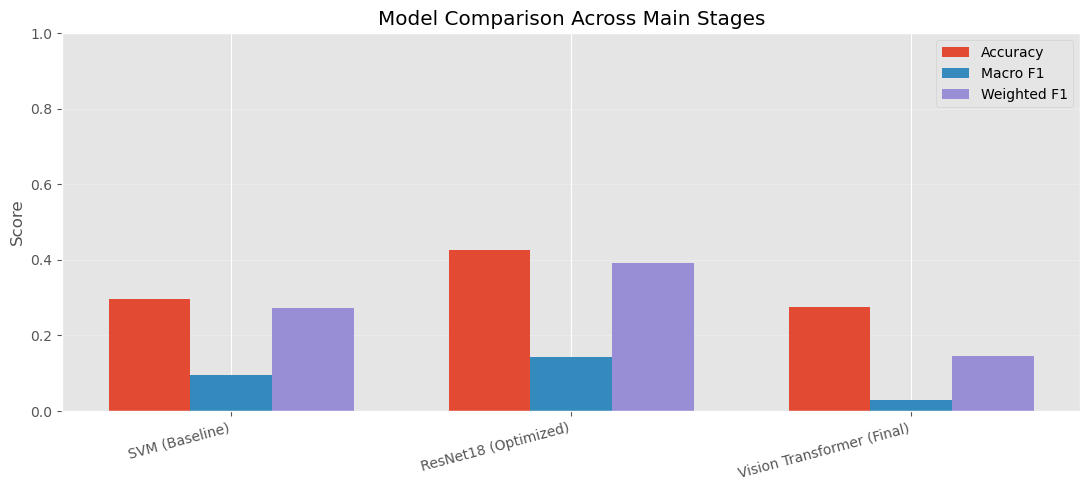

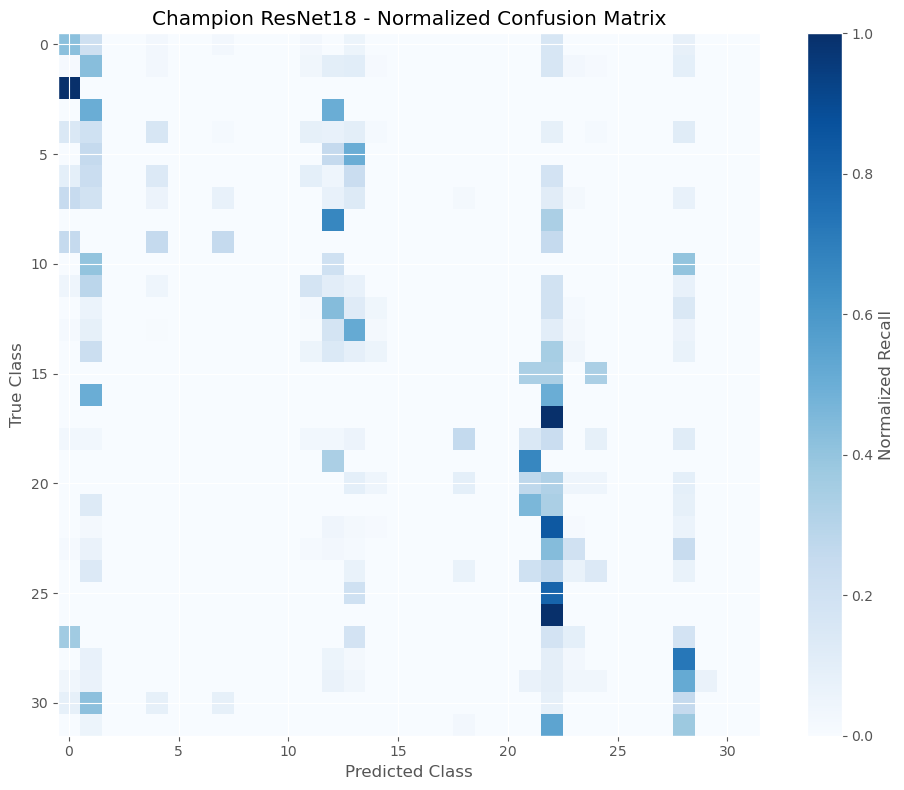

Top 3 most confused class pairs (Champion ResNet18):
- Trunks -> Shorts: 1.000
- Cutoffs -> Shorts: 1.000
- Bomber -> Blazer: 1.000


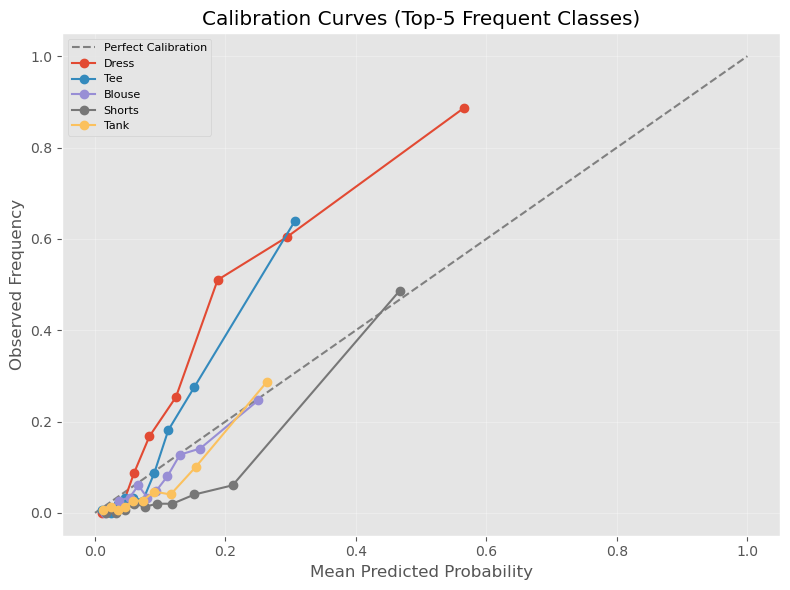

Running t-SNE on 1494 samples...


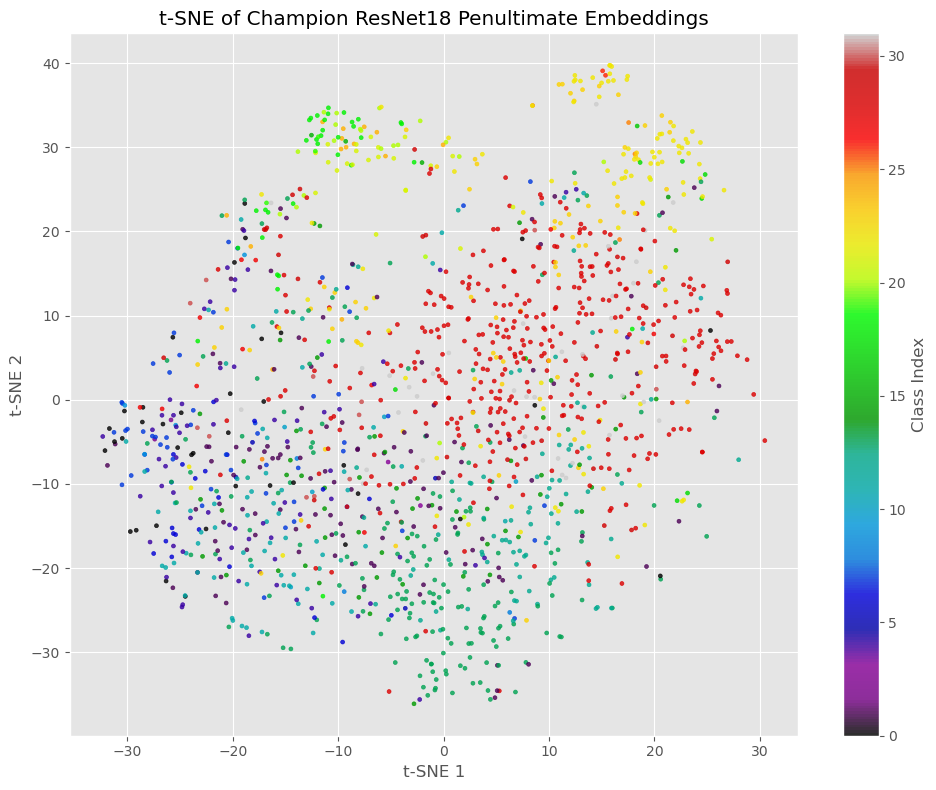

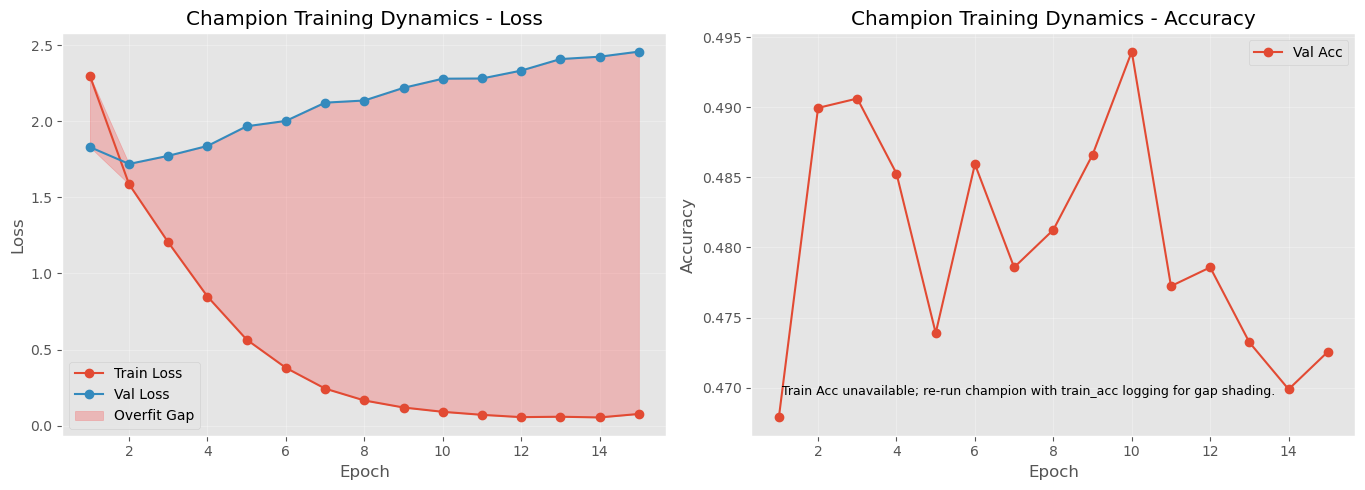

Step 5.2 complete in 21.29s


In [135]:
# Step 5.2: Professional Visualization & Error Analysis
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE

t0 = time.time()

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for embedding extraction in this analysis step.')
device = torch.device('cuda')

def get_label_name(class_idx):
    if 'idx_to_name' in globals() and 'idx_to_orig' in globals():
        orig = idx_to_orig.get(int(class_idx), int(class_idx))
        return str(idx_to_name.get(orig, f'Class_{orig}'))
    if 'idx_to_name' in globals():
        return str(idx_to_name.get(int(class_idx), f'Class_{class_idx}'))
    return f'Class_{class_idx}'

def predict_with_probs(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            y_prob.append(probs)
            y_pred.extend(preds.tolist())
            y_true.extend(yb.numpy().tolist())
    return np.array(y_true), np.array(y_pred), np.vstack(y_prob)

# ------------------------------------------------------------
# 1) Model comparison chart: Accuracy, Macro-F1, Weighted-F1
# ------------------------------------------------------------
results = []

if 'svm_pred' in globals() and 'y_test' in globals():
    y_true_svm = np.array(y_test)
    y_pred_svm = np.array(svm_pred)
    results.append({
        'Model': 'SVM (Baseline)',
        'Accuracy': accuracy_score(y_true_svm, y_pred_svm),
        'Macro F1': f1_score(y_true_svm, y_pred_svm, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true_svm, y_pred_svm, average='weighted', zero_division=0),
    })
else:
    print('Warning: SVM predictions not found (expected svm_pred + y_test).')

mlp_found = False
if 'mlp_true' in globals() and 'mlp_pred' in globals():
    y_true_mlp = np.array(mlp_true)
    y_pred_mlp = np.array(mlp_pred)
    mlp_found = True
elif 'all_true_mlp' in globals() and 'all_preds_mlp' in globals():
    y_true_mlp = np.array(all_true_mlp)
    y_pred_mlp = np.array(all_preds_mlp)
    mlp_found = True

if mlp_found:
    results.append({
        'Model': 'MLP (Neural Bridge)',
        'Accuracy': accuracy_score(y_true_mlp, y_pred_mlp),
        'Macro F1': f1_score(y_true_mlp, y_pred_mlp, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true_mlp, y_pred_mlp, average='weighted', zero_division=0),
    })
else:
    print('Warning: MLP predictions not found. Re-run Step 4.3 and save mlp_true/mlp_pred for full comparison.')

if 'champion' in globals() and 'test_loader' in globals():
    y_true_resnet, y_pred_resnet, y_prob_resnet = predict_with_probs(champion, test_loader, device)
    results.append({
        'Model': 'ResNet18 (Optimized)',
        'Accuracy': accuracy_score(y_true_resnet, y_pred_resnet),
        'Macro F1': f1_score(y_true_resnet, y_pred_resnet, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true_resnet, y_pred_resnet, average='weighted', zero_division=0),
    })
else:
    raise RuntimeError('Champion ResNet18 or test_loader not found. Run Step 4.5/4.6 first.')

if 'vit_model' in globals() and 'test_loader' in globals():
    y_true_vit, y_pred_vit, y_prob_vit = predict_with_probs(vit_model, test_loader, device)
    results.append({
        'Model': 'Vision Transformer (Final)',
        'Accuracy': accuracy_score(y_true_vit, y_pred_vit),
        'Macro F1': f1_score(y_true_vit, y_pred_vit, average='macro', zero_division=0),
        'Weighted F1': f1_score(y_true_vit, y_pred_vit, average='weighted', zero_division=0),
    })
else:
    print('Warning: ViT model not found. Re-run Step 4.7 for full comparison chart.')

results_df = pd.DataFrame(results)
display(results_df.round(4))

metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
x = np.arange(len(results_df))
width = 0.24
plt.figure(figsize=(11, 5))
for i, m in enumerate(metrics):
    plt.bar(x + (i - 1) * width, results_df[m].values, width=width, label=m)
plt.xticks(x, results_df['Model'].values, rotation=15, ha='right')
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Comparison Across Main Stages')
plt.legend()
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2) Failure mode analysis: normalized confusion matrix (Champion)
# ------------------------------------------------------------
cm = confusion_matrix(y_true_resnet, y_pred_resnet, normalize='true')
num_classes_cm = cm.shape[0]
class_names = [get_label_name(i) for i in range(num_classes_cm)]

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Normalized Recall')
plt.title('Champion ResNet18 - Normalized Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

off_diag = cm.copy()
np.fill_diagonal(off_diag, 0.0)
flat_idx = np.argsort(off_diag.ravel())[::-1]
top3 = []
for idx in flat_idx:
    r, c = np.unravel_index(idx, off_diag.shape)
    if off_diag[r, c] <= 0:
        continue
    top3.append((r, c, off_diag[r, c]))
    if len(top3) == 3:
        break

print('Top 3 most confused class pairs (Champion ResNet18):')
for r, c, val in top3:
    print(f'- {class_names[r]} -> {class_names[c]}: {val:.3f}')

# ------------------------------------------------------------
# 3) Reliability curve (calibration) for top-5 frequent classes
# ------------------------------------------------------------
class_counts = np.bincount(y_true_resnet, minlength=y_prob_resnet.shape[1])
top5_classes = np.argsort(class_counts)[::-1][:5]

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')
for cls_idx in top5_classes:
    y_bin = (y_true_resnet == cls_idx).astype(int)
    prob_cls = y_prob_resnet[:, cls_idx]
    frac_pos, mean_pred = calibration_curve(y_bin, prob_cls, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=get_label_name(cls_idx))
plt.title('Calibration Curves (Top-5 Frequent Classes)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Frequency')
plt.legend(loc='best', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) Feature space visualization with t-SNE (Champion embeddings)
# ------------------------------------------------------------
feature_extractor = nn.Sequential(*(list(champion.children())[:-1])).to(device)
feature_extractor.eval()
embeddings = []
labels = []
max_points = 3000

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device, non_blocking=True)
        feats = feature_extractor(xb).flatten(1).cpu().numpy()
        embeddings.append(feats)
        labels.append(yb.numpy())
        if sum(len(a) for a in labels) >= max_points:
            break

X_emb = np.vstack(embeddings)[:max_points]
y_emb = np.concatenate(labels)[:max_points]

print(f'Running t-SNE on {len(y_emb)} samples...')
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=30)
X_2d = tsne.fit_transform(X_emb)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_emb, s=8, cmap='nipy_spectral', alpha=0.8)
plt.title('t-SNE of Champion ResNet18 Penultimate Embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
cbar = plt.colorbar(scatter)
cbar.set_label('Class Index')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5) Training dynamics: loss + accuracy with overfitting gap shading
# ------------------------------------------------------------
if 'champion_history_46' in globals():
    hist = champion_history_46
elif 'champion_history' in globals():
    hist = champion_history
else:
    hist = None

if hist is None:
    print('Champion history not found. Cannot draw training dynamics plot.')
else:
    tr_loss = np.array(hist.get('train_loss', []), dtype=float)
    va_loss = np.array(hist.get('val_loss', []), dtype=float)
    tr_acc = np.array(hist.get('train_acc', []), dtype=float)
    va_acc = np.array(hist.get('val_acc', []), dtype=float)

    n_epochs = max(len(tr_loss), len(va_loss), len(tr_acc), len(va_acc))
    epochs = np.arange(1, n_epochs + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if len(tr_loss) == len(epochs) and len(va_loss) == len(epochs):
        axes[0].plot(epochs, tr_loss, marker='o', label='Train Loss')
        axes[0].plot(epochs, va_loss, marker='o', label='Val Loss')
        axes[0].fill_between(epochs, np.minimum(tr_loss, va_loss), np.maximum(tr_loss, va_loss), alpha=0.2, color='red', label='Overfit Gap')
    else:
        axes[0].text(0.05, 0.5, 'Loss history unavailable', transform=axes[0].transAxes)
    axes[0].set_title('Champion Training Dynamics - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc='best')

    if len(tr_acc) == len(epochs) and len(va_acc) == len(epochs):
        axes[1].plot(epochs, tr_acc, marker='o', label='Train Acc')
        axes[1].plot(epochs, va_acc, marker='o', label='Val Acc')
        axes[1].fill_between(epochs, np.minimum(tr_acc, va_acc), np.maximum(tr_acc, va_acc), alpha=0.2, color='orange', label='Generalization Gap')
    elif len(va_acc) == len(epochs):
        axes[1].plot(epochs, va_acc, marker='o', label='Val Acc')
        axes[1].text(0.05, 0.1, 'Train Acc unavailable; re-run champion with train_acc logging for gap shading.', transform=axes[1].transAxes, fontsize=9)
    else:
        axes[1].text(0.05, 0.5, 'Accuracy history unavailable', transform=axes[1].transAxes)
    axes[1].set_title('Champion Training Dynamics - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

print(f'Step 5.2 complete in {time.time() - t0:.2f}s')
